# EV Charging Midterm - Full Amalgamation, Clustering, Classification, Regression, and Explainability

## 1. Business Case and Value
This notebook identifies California tracts that are **least desirable, more desirable, or most desirable** for EV charging infrastructure investment.

### Business objective
We want to find tracts where:
- EV demand is strong,
- existing charging supply is relatively low,
- and local socioeconomic / housing / commuting context supports future EV charging growth.

### Working hypotheses
- Tracts with stronger EV demand and weaker charger supply are more desirable for investment.
- Adding county-level EV demand features improves the base tract dataset.
- Adding charging-supply context improves the investment story further.
- Latent variables built from demand, supply, housing, and commuting context improve model quality and interpretation.
- A **two-stage golden cluster** can isolate the strongest opportunity subset more precisely than one-pass clustering.

## 2. Setup, Drive Paths, and Reproducibility
We cache datasets, save models, and save outputs in the project folder.  
If a model already exists, the notebook loads it instead of retraining.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import os
import gdown

BASE_DIR_CANDIDATES = [
    Path('/content/drive/MyDrive/ML-Spring-2026/Unsupervised Learners/EV_Numeric Project'),
    Path('/content/drive/MyDrive/Unsupervised Learners/EV_Numeric Project'),
    Path('/content/drive/Shareddrives/Unsupervised Learners/EV_Numeric Project'),
    Path('/content/drive/Shared drives/Unsupervised Learners/EV_Numeric Project'),
]

BASE_DIR = next((p for p in BASE_DIR_CANDIDATES if p.exists()), None)
if BASE_DIR is None:
    raise FileNotFoundError("Could not find the Unsupervised Learners folder in Drive.")

try:
    CACHE_DIR = BASE_DIR / 'cache'
    MODEL_DIR = BASE_DIR / 'saved_models'
    OUTPUT_DIR = BASE_DIR / 'outputs'
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
except OSError:
    print("Could not create subfolders. Using project folder directly.")
    CACHE_DIR = BASE_DIR
    MODEL_DIR = BASE_DIR
    OUTPUT_DIR = BASE_DIR

DATASET_1_ID = '1zrC8fwuSb9n_i_dvDQqw9E3jWoMf6_-_'
DATASET_2_ID = '1cH8tiYmEOAj-ZUM0rvJHuStpvMFYDbDC'
DATASET_3_ID = '1zK7_DMPw1ddRQUk551sXyNacAEJ8hX37'

DATASET_1_PATH = CACHE_DIR / 'dataset1.xlsx'
DATASET_2_PATH = CACHE_DIR / 'dataset2.csv'
DATASET_3_PATH = CACHE_DIR / 'dataset3.csv'

def download_dataset(file_id, output_path):
    if output_path.exists():
        print(f'✓ Using cached {output_path.name}')
        return output_path
    url = f'https://drive.google.com/uc?id={file_id}'
    gdown.download(url, str(output_path), quiet=False, fuzzy=True)
    print(f'✓ Downloaded {output_path.name}')
    return output_path

download_dataset(DATASET_1_ID, DATASET_1_PATH)
download_dataset(DATASET_2_ID, DATASET_2_PATH)
download_dataset(DATASET_3_ID, DATASET_3_PATH)

print("BASE_DIR       =", BASE_DIR)
print("CACHE_DIR      =", CACHE_DIR)
print("MODEL_DIR      =", MODEL_DIR)
print("OUTPUT_DIR     =", OUTPUT_DIR)
print("DATASET_1_PATH =", DATASET_1_PATH)
print("DATASET_2_PATH =", DATASET_2_PATH)
print("DATASET_3_PATH =", DATASET_3_PATH)

Mounted at /content/drive


Downloading...
From: https://drive.google.com/uc?id=1zrC8fwuSb9n_i_dvDQqw9E3jWoMf6_-_
To: /content/drive/MyDrive/ML-Spring-2026/Unsupervised Learners/EV_Numeric Project/cache/dataset1.xlsx
100%|██████████| 2.05M/2.05M [00:00<00:00, 152MB/s]


✓ Downloaded dataset1.xlsx


Downloading...
From: https://drive.google.com/uc?id=1cH8tiYmEOAj-ZUM0rvJHuStpvMFYDbDC
To: /content/drive/MyDrive/ML-Spring-2026/Unsupervised Learners/EV_Numeric Project/cache/dataset2.csv
100%|██████████| 726k/726k [00:00<00:00, 118MB/s]


✓ Downloaded dataset2.csv


Downloading...
From: https://drive.google.com/uc?id=1zK7_DMPw1ddRQUk551sXyNacAEJ8hX37
To: /content/drive/MyDrive/ML-Spring-2026/Unsupervised Learners/EV_Numeric Project/cache/dataset3.csv
100%|██████████| 29.1M/29.1M [00:00<00:00, 41.0MB/s]

✓ Downloaded dataset3.csv
BASE_DIR       = /content/drive/MyDrive/ML-Spring-2026/Unsupervised Learners/EV_Numeric Project
CACHE_DIR      = /content/drive/MyDrive/ML-Spring-2026/Unsupervised Learners/EV_Numeric Project/cache
MODEL_DIR      = /content/drive/MyDrive/ML-Spring-2026/Unsupervised Learners/EV_Numeric Project/saved_models
OUTPUT_DIR     = /content/drive/MyDrive/ML-Spring-2026/Unsupervised Learners/EV_Numeric Project/outputs
DATASET_1_PATH = /content/drive/MyDrive/ML-Spring-2026/Unsupervised Learners/EV_Numeric Project/cache/dataset1.xlsx
DATASET_2_PATH = /content/drive/MyDrive/ML-Spring-2026/Unsupervised Learners/EV_Numeric Project/cache/dataset2.csv
DATASET_3_PATH = /content/drive/MyDrive/ML-Spring-2026/Unsupervised Learners/EV_Numeric Project/cache/dataset3.csv


## 3. Libraries and Helpers
We use:
- **pandas** for tabular data preparation,
- **matplotlib / seaborn / ydata-profiling** for visualization and automated EDA,
- **scikit-learn / imbalanced-learn** for clustering, classification, regression, and SMOTE,
- **SHAP** for explainability.

In [ ]:
!pip install -q openpyxl joblib shap imbalanced-learn ipywidgets ydata-profiling

import warnings, json, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, clear_output
import ipywidgets as widgets

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, label_binarize
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
    roc_auc_score, mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              RandomForestRegressor, GradientBoostingRegressor)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

def safe_div(a, b):
    a = pd.to_numeric(a, errors='coerce')
    b = pd.to_numeric(b, errors='coerce')
    return np.where(b > 0, a / b, np.nan)

def model_path(name: str):
    return MODEL_DIR / f"{name}.joblib"

def load_model(name: str):
    p = model_path(name)
    return joblib.load(p) if p.exists() else None

def save_model(model, name: str):
    p = model_path(name)
    joblib.dump(model, p)
    print(f"Saved model to: {p}")
    return p

def feature_missing_table(df):
    return pd.DataFrame({
        'missing_count': df.isna().sum(),
        'missing_pct': (df.isna().mean() * 100).round(2)
    }).sort_values('missing_pct', ascending=False)

def show_distribution(df, cols):
    fig, axes = plt.subplots(len(cols), 1, figsize=(8, 3*len(cols)))
    if len(cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, cols):
        df[col].dropna().hist(ax=ax, bins=40)
        ax.set_title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

print("✓ All libraries imported successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 126.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 95.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 8.7 MB/s eta 0:00:00
✓ All libraries imported successfully


## 4. Load the Three Datasets
We start by loading the three raw datasets.

### Dataset roles in this notebook
- **Dataset 1 (ZEV Sales):** EV / ZEV sales by county, quarter, make, model (2008–2025)
- **Dataset 2 (ACS Tracts):** ACS 2022 census-tract socioeconomic data — the base table
- **Dataset 3 (Alt Fuel Stations):** EV charging station locations and charger counts

In [ ]:
raw_d1 = pd.read_excel(DATASET_1_PATH)
raw_d2 = pd.read_csv(DATASET_2_PATH)
raw_d3 = pd.read_csv(DATASET_3_PATH)

print("Dataset 1 shape:", raw_d1.shape)
display(raw_d1.head())
print("Dataset 2 shape:", raw_d2.shape)
display(raw_d2.head())
print("Dataset 3 shape:", raw_d3.shape)
display(raw_d3.head())

Dataset 1 shape: (72384, 7)


,Data Year,Quarter,COUNTY,FUEL_TYPE,MAKE,MODEL,Number of Vehicles
0,2008,3,Alameda,Electric,Tesla,Roadster,1
1,2008,3,San Francisco,Electric,Tesla,Roadster,1
2,2008,3,San Mateo,Electric,Tesla,Roadster,3
3,2008,3,Santa Clara,Electric,Tesla,Roadster,4
4,2008,3,Sonoma,Electric,Tesla,Roadster,1


Dataset 2 shape: (9129, 18)


,GEOID,total_population,median_household_income,total_households,households_0_vehicles,households_1_vehicle,households_2_vehicles,households_3_vehicles,households_4_vehicles,households_5plus_vehicles,total_workers_commuting,total_housing_units,housing_units_2_units,housing_units_3_4_units,housing_units_5_9_units,housing_units_10_19_units,housing_units_20_49_units,housing_units_50plus_units
0,6001400100,3269,234236.0,1377,95,441,614,174,53,361,1582,1496,0,0,8,0,0,0
1,6001400200,2147,225500.0,876,83,445,277,52,19,225,1124,913,23,73,105,104,9,3
2,6001400300,5619,164000.0,2638,367,1475,658,109,29,1095,3301,2851,230,421,278,55,237,342
3,6001400400,4278,158836.0,1760,249,820,535,135,21,638,2455,1975,270,335,188,48,69,0
4,6001400500,3949,95078.0,1679,143,703,675,112,46,512,2210,1820,198,230,185,207,36,8


Dataset 3 shape: (84681, 75)


,Fuel Type Code,Station Name,Street Address,Intersection Directions,City,State,ZIP,Plus4,Station Phone,Status Code,Expected Date,Groups With Access Code,Access Days Time,Cards Accepted,BD Blends,NG Fill Type Code,NG PSI,EV Level1 EVSE Num,EV Level2 EVSE Num,EV DC Fast Count,EV Other Info,EV Network,EV Network Web,Geocode Status,Latitude,Longitude,Date Last Confirmed,ID,Updated At,Owner Type Code,Federal Agency ID,Federal Agency Name,Open Date,Hydrogen Status Link,NG Vehicle Class,LPG Primary,E85 Blender Pump,EV Connector Types,Country,Intersection Directions (French),Access Days Time (French),BD Blends (French),Groups With Access Code (French),Hydrogen Is Retail,Access Code,Access Detail Code,Federal Agency Code,Facility Type,CNG Dispenser Num,CNG On-Site Renewable Source,CNG Total Compression Capacity,CNG Storage Capacity,LNG On-Site Renewable Source,E85 Other Ethanol Blends,EV Pricing,EV Pricing (French),LPG Nozzle Types,Hydrogen Pressures,Hydrogen Standards,CNG Fill Type Code,CNG PSI,CNG Vehicle Class,LNG Vehicle Class,EV On-Site Renewable Source,Restricted Access,RD Blends,RD Blends (French),RD Blended with Biodiesel,RD Maximum Biodiesel Level,NPS Unit Name,CNG Station Sells Renewable Natural Gas,LNG Station Sells Renewable Natural Gas,Maximum Vehicle Class,EV Workplace Charging,Funding Sources
0,ELEC,LADWP - Truesdale Center,11797 Truesdale St,NaN,Sun Valley,CA,91352.0,NaN,NaN,E,NaN,Private,For fleet use only,NaN,NaN,NaN,NaN,NaN,57.0,2.0,NaN,SHELL_RECHARGE,https://www.shell.us/motorist/electric-vehicle...,GPS,34.248319,-118.387971,2025-11-13,1517,2025-11-13 20:02:17 UTC,LG,NaN,NaN,1999-10-15,NaN,NaN,NaN,NaN,CHADEMO J1772 J1772COMBO,US,NaN,NaN,NaN,Privé,NaN,private,NaN,NaN,UTILITY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MD,True,NaN
1,ELEC,Los Angeles Convention Center,1201 S Figueroa St,West hall and South hall,Los Angeles,CA,90015.0,NaN,213-741-1151,E,NaN,Public,5:30am-9pm; pay lot,NaN,NaN,NaN,NaN,NaN,8.0,NaN,NaN,Non-Networked,NaN,GPS,34.040539,-118.271387,2025-12-12,1523,2025-12-12 22:53:25 UTC,P,NaN,NaN,1995-08-30,NaN,NaN,NaN,NaN,J1772,US,NaN,NaN,NaN,Public,NaN,public,NaN,NaN,PARKING_GARAGE,NaN,NaN,NaN,NaN,NaN,NaN,Free,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LD,False,NaN
2,ELEC,LADWP - John Ferraro Building,111 N Hope St,Across Hope,Los Angeles,CA,90012.0,NaN,NaN,E,NaN,Private,For fleet and employee use only,NaN,NaN,NaN,NaN,NaN,379.0,15.0,NaN,Non-Networked,NaN,GPS,34.059133,-118.248589,2025-11-13,1525,2025-11-13 20:02:17 UTC,LG,NaN,NaN,1999-10-15,NaN,NaN,NaN,NaN,CHADEMO J1772 J1772COMBO,US,NaN,NaN,NaN,Privé,NaN,private,NaN,NaN,UTILITY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LD,True,NaN
3,ELEC,LADWP - Haynes Power Plant,6801 E 2nd St,NaN,Long Beach,CA,90803.0,NaN,NaN,E,NaN,Private,For fleet use only,NaN,NaN,NaN,NaN,NaN,31.0,NaN,NaN,Non-Networked,NaN,GPS,33.759802,-118.096665,2025-11-13,1531,2025-11-13 20:02:17 UTC,LG,NaN,NaN,2018-05-01,NaN,NaN,NaN,NaN,J1772,US,NaN,NaN,NaN,Privé,NaN,private,NaN,NaN,UTILITY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LD,True,NaN
4,ELEC,LADWP - Harbor Generating Station,161 N Island Ave,At B St,Wilmington,CA,90744.0,NaN,NaN,E,NaN,Private,For fleet use only,NaN,NaN,NaN,NaN,NaN,12.0,NaN,NaN,Non-Networked,NaN,200-8,33.770508,-118.265628,2025-11-13,1552,2025-11-13 20:02:17 UTC,LG,NaN,NaN,1999-10-15,NaN,NaN,NaN,NaN,J1772,US,NaN,NaN,NaN,Privé,NaN,private,NaN,NaN,UTILITY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LD,True,NaN


## 5. Final Unit of Analysis and Merge Strategy
We use **Census tracts** as the final modeling unit because county-level aggregation would leave too few rows.

### Merge design
- **Dataset 2 (ACS tract table)** becomes the base dataset.
- **Dataset 1 (EV demand)** is filtered to 2022 and aggregated to county level.
- **Dataset 3 (charging stations)** is filtered to active CA EV stations, then aggregated to county level.
- County-level features are then attached to each tract through a GEOID-derived county mapping.

## 6. Base Dataset Preprocessing - ACS 2022 Tracts
This dataset already has the right granularity and enough rows for ML.  
We keep it as the base table and ensure GEOID is a clean unique tract key.

In [ ]:
df_base = raw_d2.copy()
df_base['GEOID'] = df_base['GEOID'].astype(str)

print("Base dataset shape:", df_base.shape)
print("Duplicate GEOIDs:", df_base['GEOID'].duplicated().sum())
display(feature_missing_table(df_base).head(20))
display(df_base.head())

Base dataset shape: (9129, 18)
Duplicate GEOIDs: 0


,missing_count,missing_pct
median_household_income,141,1.54
GEOID,0,0.00
total_population,0,0.00
total_households,0,0.00
households_0_vehicles,0,0.00
households_1_vehicle,0,0.00
households_2_vehicles,0,0.00
households_3_vehicles,0,0.00
households_4_vehicles,0,0.00
households_5plus_vehicles,0,0.00


,GEOID,total_population,median_household_income,total_households,households_0_vehicles,households_1_vehicle,households_2_vehicles,households_3_vehicles,households_4_vehicles,households_5plus_vehicles,total_workers_commuting,total_housing_units,housing_units_2_units,housing_units_3_4_units,housing_units_5_9_units,housing_units_10_19_units,housing_units_20_49_units,housing_units_50plus_units
0,6001400100,3269,234236.0,1377,95,441,614,174,53,361,1582,1496,0,0,8,0,0,0
1,6001400200,2147,225500.0,876,83,445,277,52,19,225,1124,913,23,73,105,104,9,3
2,6001400300,5619,164000.0,2638,367,1475,658,109,29,1095,3301,2851,230,421,278,55,237,342
3,6001400400,4278,158836.0,1760,249,820,535,135,21,638,2455,1975,270,335,188,48,69,0
4,6001400500,3949,95078.0,1679,143,703,675,112,46,512,2210,1820,198,230,185,207,36,8


## 7. Dataset 1 Preprocessing - EV Demand
Because the ACS table is a **2022 snapshot**, we filter EV demand to **2022** before aggregation.  
Then we aggregate EV demand to county level so it can be merged into the tract base.

In [ ]:
df_demand = raw_d1.copy()
df_demand_2022 = df_demand[df_demand['Data Year'] == 2022].copy()

df_demand_2022['county_name'] = (
    df_demand_2022['COUNTY']
    .astype(str)
    .str.strip()
    .str.title()
)

df_demand_county = (
    df_demand_2022.groupby('county_name', as_index=False)
    .agg(
        total_ev_vehicles=('Number of Vehicles', 'sum'),
        unique_fuel_types=('FUEL_TYPE', 'nunique'),
        unique_makes=('MAKE', 'nunique'),
        unique_models=('MODEL', 'nunique')
    )
)

print("Filtered EV demand shape (2022):", df_demand_2022.shape)
print("County-level EV demand shape:", df_demand_county.shape)
display(df_demand_county.head(10))

Filtered EV demand shape (2022): (7558, 8)
County-level EV demand shape: (59, 5)


,county_name,total_ev_vehicles,unique_fuel_types,unique_makes,unique_models
0,Alameda,17788,3,31,79
1,Alpine,6,2,6,6
2,Amador,87,2,14,24
3,Butte,406,2,21,41
4,Calaveras,126,2,17,32
5,Colusa,28,2,8,12
6,Contra Costa,11139,3,31,79
7,Del Norte,11,2,7,10
8,El Dorado,1182,3,24,58
9,Fresno,2897,3,28,68


## 8. Derive County Name from Tract GEOID
The ACS base table does not directly contain county names.  
We derive county FIPS from GEOID and map those FIPS codes to California county names.  
This gives us the tract-to-county bridge needed for both enrichments.

In [ ]:
county_fips_to_name = {
    '001':'Alameda','003':'Alpine','005':'Amador','007':'Butte','009':'Calaveras',
    '011':'Colusa','013':'Contra Costa','015':'Del Norte','017':'El Dorado','019':'Fresno',
    '021':'Glenn','023':'Humboldt','025':'Imperial','027':'Inyo','029':'Kern',
    '031':'Kings','033':'Lake','035':'Lassen','037':'Los Angeles','039':'Madera',
    '041':'Marin','043':'Mariposa','045':'Mendocino','047':'Merced','049':'Modoc',
    '051':'Mono','053':'Monterey','055':'Napa','057':'Nevada','059':'Orange',
    '061':'Placer','063':'Plumas','065':'Riverside','067':'Sacramento','069':'San Benito',
    '071':'San Bernardino','073':'San Diego','075':'San Francisco','077':'San Joaquin','079':'San Luis Obispo',
    '081':'San Mateo','083':'Santa Barbara','085':'Santa Clara','087':'Santa Cruz','089':'Shasta',
    '091':'Sierra','093':'Siskiyou','095':'Solano','097':'Sonoma','099':'Stanislaus',
    '101':'Sutter','103':'Tehama','105':'Trinity','107':'Tulare','109':'Tuolumne',
    '111':'Ventura','113':'Yolo','115':'Yuba'
}

df1 = df_base.copy()
# GEOID format: 6001400100 -> zfill to 11 -> '06001400100' -> chars [2:5] = '001' (county fips)
df1['county_fips'] = df1['GEOID'].str.zfill(11).str[2:5]
df1['county_name'] = df1['county_fips'].map(county_fips_to_name)

print("Unique counties in tract base:", df1['county_name'].nunique())
print("Tracts with null county:", df1['county_name'].isnull().sum())
display(df1[['GEOID', 'county_fips', 'county_name']].head(10))

Unique counties in tract base: 58
Tracts with null county: 0


,GEOID,county_fips,county_name
0,6001400100,001,Alameda
1,6001400200,001,Alameda
2,6001400300,001,Alameda
3,6001400400,001,Alameda
4,6001400500,001,Alameda
5,6001400600,001,Alameda
6,6001400700,001,Alameda
7,6001400800,001,Alameda
8,6001400900,001,Alameda
9,6001401000,001,Alameda


## 9. Amalgamation 1 - Dataset 1 + Dataset 2
We attach county-level EV demand to every tract in the same county.  
A left merge preserves all tracts from the base table.

In [ ]:
df12 = df1.merge(df_demand_county, on='county_name', how='left')

added_demand_cols = [c for c in df_demand_county.columns if c != 'county_name']
print("Shape after Amalgamation 1:", df12.shape)
display(df12[['GEOID','county_name'] + added_demand_cols].head(10))
print("Missingness in EV demand features:")
display(df12[added_demand_cols].isna().sum().to_frame('missing_count'))

Shape after Amalgamation 1: (9129, 24)


,GEOID,county_name,total_ev_vehicles,unique_fuel_types,unique_makes,unique_models
0,6001400100,Alameda,17788,3,31,79
1,6001400200,Alameda,17788,3,31,79
2,6001400300,Alameda,17788,3,31,79
3,6001400400,Alameda,17788,3,31,79
4,6001400500,Alameda,17788,3,31,79
5,6001400600,Alameda,17788,3,31,79
6,6001400700,Alameda,17788,3,31,79
7,6001400800,Alameda,17788,3,31,79
8,6001400900,Alameda,17788,3,31,79
9,6001401000,Alameda,17788,3,31,79


Missingness in EV demand features:


,missing_count
total_ev_vehicles,0
unique_fuel_types,0
unique_makes,0
unique_models,0


## 10. Dataset 3 Preprocessing - Charging Infrastructure
We clean the charging station dataset and retain key geographic and charger-supply fields.

**FIX applied:** We now filter to **active stations only** (Status Code == 'E') before aggregating,
so temporary (T) and planned (P) stations do not inflate county supply counts.

In [ ]:
df_supply = raw_d3.copy()
df_supply.columns = (
    df_supply.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('-', '_')
)

col_mapping = {
    'latitude': 'latitude',
    'longitude': 'longitude',
    'zip': 'zip_code',
    'city': 'city',
    'state': 'state',
    'status_code': 'status_code',
    'ev_level1_evse_num': 'level1_chargers',
    'ev_level2_evse_num': 'level2_chargers',
    'ev_dc_fast_count': 'dc_fast_chargers',
}

selected = {k: v for k, v in col_mapping.items() if k in df_supply.columns}
df_supply = df_supply[list(selected.keys())].rename(columns=selected)

# Filter: California only
if 'state' in df_supply.columns:
    df_supply = df_supply[df_supply['state'].astype(str).str.upper().isin(['CA', 'CALIFORNIA'])].copy()

# FIX: Filter to active stations only (Status Code = 'E').
# Temporary ('T') and planned ('P') stations should not count as existing supply.
if 'status_code' in df_supply.columns:
    before_filter = len(df_supply)
    df_supply = df_supply[df_supply['status_code'].astype(str).str.upper() == 'E'].copy()
    print(f"Active-station filter: kept {len(df_supply)} of {before_filter} CA records")

for c in ['level1_chargers', 'level2_chargers', 'dc_fast_chargers']:
    if c in df_supply.columns:
        df_supply[c] = pd.to_numeric(df_supply[c], errors='coerce').fillna(0)

sum_cols = [c for c in ['level1_chargers', 'level2_chargers', 'dc_fast_chargers'] if c in df_supply.columns]
df_supply['total_chargers'] = df_supply[sum_cols].sum(axis=1) if sum_cols else 0

print("Charging supply cleaned shape:", df_supply.shape)
display(feature_missing_table(df_supply).head(10))
display(df_supply.head())

Active-station filter: kept 20064 of 20452 CA records
Charging supply cleaned shape: (20064, 10)


,missing_count,missing_pct
latitude,0,0.0
longitude,0,0.0
zip_code,1,0.0
city,1,0.0
state,0,0.0
status_code,0,0.0
level1_chargers,0,0.0
level2_chargers,0,0.0
dc_fast_chargers,0,0.0
total_chargers,0,0.0


,latitude,longitude,zip_code,city,state,status_code,level1_chargers,level2_chargers,dc_fast_chargers,total_chargers
0,34.248319,-118.387971,91352.0,Sun Valley,CA,E,0.0,57.0,2.0,59.0
1,34.040539,-118.271387,90015.0,Los Angeles,CA,E,0.0,8.0,0.0,8.0
2,34.059133,-118.248589,90012.0,Los Angeles,CA,E,0.0,379.0,15.0,394.0
3,33.759802,-118.096665,90803.0,Long Beach,CA,E,0.0,31.0,0.0,31.0
4,33.770508,-118.265628,90744.0,Wilmington,CA,E,0.0,12.0,0.0,12.0


## 11. Derive County Mapping for Charging Stations
A full GIS crosswalk is beyond the scope of this notebook, so we use a city-to-county mapping strategy.  
We use an expanded list covering the top CA cities by station count.  
The mapping flag `charging_supply_mapped` is kept so coverage limitations remain explicit.

In [ ]:
city_to_county = {
    # Major metros
    'los angeles':'Los Angeles','san diego':'San Diego','san jose':'Santa Clara',
    'san francisco':'San Francisco','fresno':'Fresno','sacramento':'Sacramento',
    'long beach':'Los Angeles','oakland':'Alameda','bakersfield':'Kern',
    'anaheim':'Orange','santa ana':'Orange','riverside':'Riverside',
    'stockton':'San Joaquin','irvine':'Orange','chula vista':'San Diego',
    'fremont':'Alameda','san bernardino':'San Bernardino','modesto':'Stanislaus',
    'fontana':'San Bernardino','oxnard':'Ventura','moreno valley':'Riverside',
    'huntington beach':'Orange','glendale':'Los Angeles','santa clarita':'Los Angeles',
    'garden grove':'Orange','oceanside':'San Diego','rancho cucamonga':'San Bernardino',
    'santa rosa':'Sonoma','ontario':'San Bernardino','elk grove':'Sacramento',
    'corona':'Riverside','palmdale':'Los Angeles','salinas':'Monterey',
    'pomona':'Los Angeles','hayward':'Alameda','escondido':'San Diego',
    'sunnyvale':'Santa Clara','orange':'Orange','fullerton':'Orange',
    'pasadena':'Los Angeles','thousand oaks':'Ventura','visalia':'Tulare',
    'simi valley':'Ventura','concord':'Contra Costa','roseville':'Placer',
    'santa clara':'Santa Clara','vallejo':'Solano','berkeley':'Alameda',
    'antioch':'Contra Costa','fairfield':'Solano','richmond':'Contra Costa',
    'murrieta':'Riverside','ventura':'Ventura','daly city':'San Mateo',
    'norwalk':'Los Angeles','jurupa valley':'Riverside','temecula':'Riverside',
    'burbank':'Los Angeles','carlsbad':'San Diego','rialto':'San Bernardino',
    'vacaville':'Solano','el cajon':'San Diego','san mateo':'San Mateo',
    'clovis':'Fresno','compton':'Los Angeles','south gate':'Los Angeles',
    'vista':'San Diego','mission viejo':'Orange','west covina':'Los Angeles',
    'merced':'Merced','santa cruz':'Santa Cruz','redding':'Shasta',
    'yuba city':'Sutter','manteca':'San Joaquin','tracy':'San Joaquin',
    'davis':'Yolo','woodland':'Yolo','napa':'Napa','petaluma':'Sonoma',
    'carson':'Los Angeles','santa barbara':'Santa Barbara','san rafael':'Marin',
    'san marcos':'San Diego','cupertino':'Santa Clara','palo alto':'Santa Clara',
    'mountain view':'Santa Clara','turlock':'Stanislaus',
    # Bay Area suburbs with high station counts
    'menlo park':'San Mateo','redwood city':'San Mateo','south san francisco':'San Mateo',
    'san bruno':'San Mateo','foster city':'San Mateo','burlingame':'San Mateo',
    'san carlos':'San Mateo','belmont':'San Mateo','millbrae':'San Mateo',
    'san leandro':'Alameda','pleasanton':'Alameda','livermore':'Alameda',
    'dublin':'Alameda','union city':'Alameda','newark':'Alameda',
    'walnut creek':'Contra Costa','san ramon':'Contra Costa','brentwood':'Contra Costa',
    'pittsburg':'Contra Costa','martinez':'Contra Costa','el cerrito':'Contra Costa',
    'santa monica':'Los Angeles','torrance':'Los Angeles','culver city':'Los Angeles',
    'el monte':'Los Angeles','hawthorne':'Los Angeles','inglewood':'Los Angeles',
    'alhambra':'Los Angeles','monterey park':'Los Angeles','whittier':'Los Angeles',
    'downey':'Los Angeles','lakewood':'Los Angeles','bellflower':'Los Angeles',
    'cerritos':'Los Angeles','carson city':'Los Angeles',
    'newport beach':'Orange','costa mesa':'Orange','santa ana':'Orange',
    'lake forest':'Orange','laguna niguel':'Orange','aliso viejo':'Orange',
    'laguna hills':'Orange','yorba linda':'Orange','brea':'Orange',
    'san clemente':'Orange','tustin':'Orange','placentia':'Orange',
    'chino':'San Bernardino','chino hills':'San Bernardino','upland':'San Bernardino',
    'victorville':'San Bernardino','hesperia':'San Bernardino','ontario':'San Bernardino',
    'el cajon':'San Diego','santee':'San Diego','la mesa':'San Diego',
    'national city':'San Diego','el centro':'Imperial',
    'oxnard':'Ventura','camarillo':'Ventura','moorpark':'Ventura',
    'san buenaventura':'Ventura',
    # Central Valley
    'tulare':'Tulare','porterville':'Tulare','hanford':'Kings',
    'madera':'Madera','chowchilla':'Madera',
    'lodi':'San Joaquin','turlock':'Stanislaus','ceres':'Stanislaus',
    # Northern CA
    'chico':'Butte','oroville':'Butte','paradise':'Butte',
    'eureka':'Humboldt','arcata':'Humboldt',
    'santa rosa':'Sonoma','rohnert park':'Sonoma','petaluma':'Sonoma',
    'ukiah':'Mendocino',
    'napa':'Napa','american canyon':'Napa',
    'fairfield':'Solano','vacaville':'Solano','dixon':'Solano',
}

df_supply['city_clean'] = df_supply['city'].astype(str).str.strip().str.lower() if 'city' in df_supply.columns else ''
df_supply['county_name'] = df_supply['city_clean'].map(city_to_county)

mapped = df_supply['county_name'].notna().sum()
total = len(df_supply)
print(f"Mapped {mapped}/{total} stations to a county ({mapped/total*100:.1f}%)")
print("Mapped counties:", df_supply['county_name'].nunique())
display(pd.DataFrame({'county_name': sorted(df_supply['county_name'].dropna().unique().tolist())}))

Mapped 14841/20064 stations to a county (74.0%)
Mapped counties: 35


,county_name
0,Alameda
1,Butte
2,Contra Costa
3,Fresno
4,Humboldt
5,Imperial
6,Kern
7,Kings
8,Los Angeles
9,Madera


## 12. County-Level Charging Supply Table
We aggregate charging-station records to county level.  
This creates stable infrastructure features for the second enrichment.

In [ ]:
agg_kwargs = {'total_stations': ('county_name', 'size')}
if 'level2_chargers' in df_supply.columns:
    agg_kwargs['total_level2_chargers'] = ('level2_chargers', 'sum')
if 'dc_fast_chargers' in df_supply.columns:
    agg_kwargs['total_dc_fast_chargers'] = ('dc_fast_chargers', 'sum')
if 'total_chargers' in df_supply.columns:
    agg_kwargs['total_chargers_sum'] = ('total_chargers', 'sum')

df_supply_county = (
    df_supply.dropna(subset=['county_name'])
    .groupby('county_name', as_index=False)
    .agg(**agg_kwargs)
)

print("County-level charging supply shape:", df_supply_county.shape)
display(df_supply_county.head(10))

County-level charging supply shape: (35, 5)


,county_name,total_stations,total_level2_chargers,total_dc_fast_chargers,total_chargers_sum
0,Alameda,837,2092.0,883.0,3051.0
1,Butte,53,113.0,55.0,168.0
2,Contra Costa,283,685.0,436.0,1123.0
3,Fresno,226,494.0,192.0,708.0
4,Humboldt,39,71.0,44.0,115.0
5,Imperial,10,16.0,70.0,86.0
6,Kern,122,246.0,191.0,438.0
7,Kings,50,75.0,9.0,84.0
8,Los Angeles,3547,13865.0,1955.0,16000.0
9,Madera,31,32.0,73.0,105.0


## 13. Amalgamation 2 - Dataset 1 + Dataset 2 + Dataset 3
We attach county-level charging supply to every tract in the same county.  
We also add a mapping indicator so we do not confuse unmapped counties with true zero infrastructure.

In [ ]:
df123 = df12.merge(df_supply_county, on='county_name', how='left')

supply_cols = [c for c in ['total_stations','total_level2_chargers','total_dc_fast_chargers','total_chargers_sum'] if c in df123.columns]
df123['charging_supply_mapped'] = np.where(df123[supply_cols].notna().any(axis=1), 1, 0)

for c in supply_cols:
    df123[c] = pd.to_numeric(df123[c], errors='coerce').fillna(0)

print("Shape after Amalgamation 2:", df123.shape)
display(df123[['GEOID','county_name'] + supply_cols + ['charging_supply_mapped']].head(10))
display(df123['charging_supply_mapped'].value_counts().rename_axis('mapped').to_frame('tract_count'))

Shape after Amalgamation 2: (9129, 29)


,GEOID,county_name,total_stations,total_level2_chargers,total_dc_fast_chargers,total_chargers_sum,charging_supply_mapped
0,6001400100,Alameda,837.0,2092.0,883.0,3051.0,1
1,6001400200,Alameda,837.0,2092.0,883.0,3051.0,1
2,6001400300,Alameda,837.0,2092.0,883.0,3051.0,1
3,6001400400,Alameda,837.0,2092.0,883.0,3051.0,1
4,6001400500,Alameda,837.0,2092.0,883.0,3051.0,1
5,6001400600,Alameda,837.0,2092.0,883.0,3051.0,1
6,6001400700,Alameda,837.0,2092.0,883.0,3051.0,1
7,6001400800,Alameda,837.0,2092.0,883.0,3051.0,1
8,6001400900,Alameda,837.0,2092.0,883.0,3051.0,1
9,6001401000,Alameda,837.0,2092.0,883.0,3051.0,1


,tract_count
mapped,
1,8789
0,340


## 14. Amalgamation 3 - Latent Variables / Latent Manifolds
We engineer latent variables from already-available features.

### Why these are appropriate
They capture hidden concepts that raw counts alone do not express directly:
- EV adoption intensity (`ev_per_1000_households`)
- Charger availability intensity (`chargers_per_1000_households`)
- Supply-demand imbalance (`supply_demand_gap`) — the core charging-desert signal
- Housing form (`multi_unit_housing_share`)
- Commuting intensity (`workers_per_household`)

In [ ]:
df123_lv = df123.copy()

if {'total_ev_vehicles','total_households'}.issubset(df123_lv.columns):
    df123_lv['ev_per_1000_households'] = safe_div(df123_lv['total_ev_vehicles'], df123_lv['total_households']) * 1000
if {'total_stations','total_households'}.issubset(df123_lv.columns):
    df123_lv['stations_per_1000_households'] = safe_div(df123_lv['total_stations'], df123_lv['total_households']) * 1000
if {'total_chargers_sum','total_households'}.issubset(df123_lv.columns):
    df123_lv['chargers_per_1000_households'] = safe_div(df123_lv['total_chargers_sum'], df123_lv['total_households']) * 1000
if {'total_dc_fast_chargers','total_ev_vehicles'}.issubset(df123_lv.columns):
    df123_lv['dc_fast_per_1000_evs'] = safe_div(df123_lv['total_dc_fast_chargers'], df123_lv['total_ev_vehicles']) * 1000
if {'total_workers_commuting','total_households'}.issubset(df123_lv.columns):
    df123_lv['workers_per_household'] = safe_div(df123_lv['total_workers_commuting'], df123_lv['total_households'])
if {'households_0_vehicles','total_households'}.issubset(df123_lv.columns):
    df123_lv['low_car_household_share'] = safe_div(df123_lv['households_0_vehicles'], df123_lv['total_households'])

multi_unit_cols = [c for c in ['housing_units_2_units','housing_units_3_4_units','housing_units_5_9_units',
                               'housing_units_10_19_units','housing_units_20_49_units','housing_units_50plus_units']
                   if c in df123_lv.columns]
if multi_unit_cols and 'total_housing_units' in df123_lv.columns:
    df123_lv['multi_unit_housing_share'] = safe_div(df123_lv[multi_unit_cols].sum(axis=1), df123_lv['total_housing_units'])

if {'total_ev_vehicles','total_chargers_sum'}.issubset(df123_lv.columns):
    df123_lv['supply_demand_gap'] = (
        pd.to_numeric(df123_lv['total_ev_vehicles'], errors='coerce') -
        pd.to_numeric(df123_lv['total_chargers_sum'], errors='coerce')
    )

latent_cols = [c for c in [
    'ev_per_1000_households','stations_per_1000_households','chargers_per_1000_households',
    'dc_fast_per_1000_evs','workers_per_household','low_car_household_share',
    'multi_unit_housing_share','supply_demand_gap'
] if c in df123_lv.columns]

print("Latent variable count:", len(latent_cols))
print(latent_cols)
display(df123_lv[['GEOID','county_name'] + latent_cols].head(10))

Latent variable count: 8
['ev_per_1000_households', 'stations_per_1000_households', 'chargers_per_1000_households', 'dc_fast_per_1000_evs', 'workers_per_household', 'low_car_household_share', 'multi_unit_housing_share', 'supply_demand_gap']


,GEOID,county_name,ev_per_1000_households,stations_per_1000_households,chargers_per_1000_households,dc_fast_per_1000_evs,workers_per_household,low_car_household_share,multi_unit_housing_share,supply_demand_gap
0,6001400100,Alameda,12917.937545,607.843137,2215.686275,49.640207,1.148874,0.068991,0.005348,14737.0
1,6001400200,Alameda,20305.936073,955.479452,3482.876712,49.640207,1.283105,0.094749,0.347207,14737.0
2,6001400300,Alameda,6742.987111,317.285823,1156.557998,49.640207,1.251327,0.139121,0.548229,14737.0
3,6001400400,Alameda,10106.818182,475.568182,1733.522727,49.640207,1.394886,0.141477,0.460759,14737.0
4,6001400500,Alameda,10594.401429,498.511018,1817.153067,49.640207,1.316260,0.085170,0.474725,14737.0
5,6001400600,Alameda,23161.458333,1089.843750,3972.656250,49.640207,1.707031,0.093750,0.427173,14737.0
6,6001400700,Alameda,8840.954274,416.003976,1516.401590,49.640207,1.540258,0.138668,0.536252,14737.0
7,6001400800,Alameda,9436.604775,444.031830,1618.567639,49.640207,1.501857,0.100265,0.594064,14737.0
8,6001400900,Alameda,15982.030548,752.021563,2741.239892,49.640207,1.744834,0.044924,0.568289,14737.0
9,6001401000,Alameda,7727.193745,363.596872,1325.369244,49.640207,1.712424,0.154648,0.478310,14737.0


## 15. Compare the Four Dataset Stages
Stage-by-stage comparison as requested.
1. Dataset 1 only (ACS tracts)
2. Dataset 1 + Dataset 2 (+ county EV demand)
3. Dataset 1 + Dataset 2 + Dataset 3 (+ county charging supply)
4. Dataset 1 + Dataset 2 + Dataset 3 + Latent Variables

In [ ]:
stage_inventory = pd.DataFrame([
    {'dataset_stage': 'Dataset 1 only', 'rows': len(df1), 'columns': df1.shape[1], 'description': 'tract ACS base'},
    {'dataset_stage': 'Dataset 1 + Dataset 2', 'rows': len(df12), 'columns': df12.shape[1], 'description': 'tract ACS + county EV demand'},
    {'dataset_stage': 'Dataset 1 + Dataset 2 + Dataset 3', 'rows': len(df123), 'columns': df123.shape[1], 'description': 'tract ACS + county EV demand + county supply'},
    {'dataset_stage': 'Dataset 1 + Dataset 2 + Dataset 3 + Latent Variable', 'rows': len(df123_lv), 'columns': df123_lv.shape[1], 'description': 'all features + engineered latent variables'},
])
display(stage_inventory)

,dataset_stage,rows,columns,description
0,Dataset 1 only,9129,20,tract ACS base
1,Dataset 1 + Dataset 2,9129,24,tract ACS + county EV demand
2,Dataset 1 + Dataset 2 + Dataset 3,9129,29,tract ACS + county EV demand + county supply
3,Dataset 1 + Dataset 2 + Dataset 3 + Latent Var...,9129,37,all features + engineered latent variables


## 16. Exploratory Data Analysis and Data Narrative
We inspect the distributions of demand, supply, and latent variables.  
This helps us explain how the investment narrative evolves after each enrichment stage.

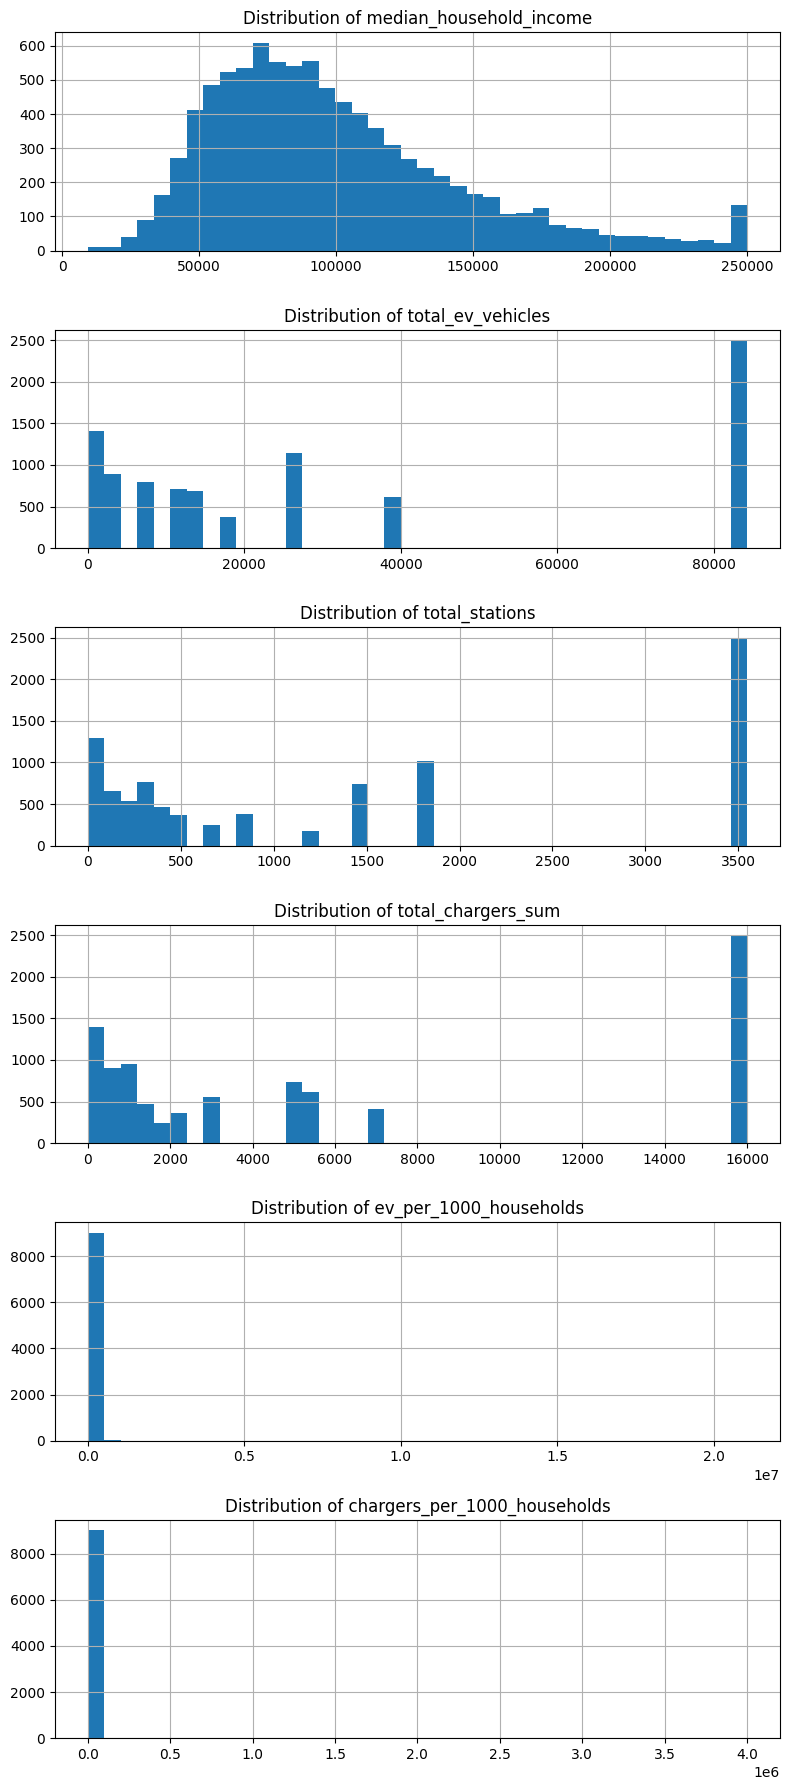

In [ ]:
eda_cols = [c for c in [
    'median_household_income','total_ev_vehicles','total_stations',
    'total_chargers_sum','ev_per_1000_households','chargers_per_1000_households','supply_demand_gap'
] if c in df123_lv.columns]

show_distribution(df123_lv, eda_cols[:min(len(eda_cols), 6)])

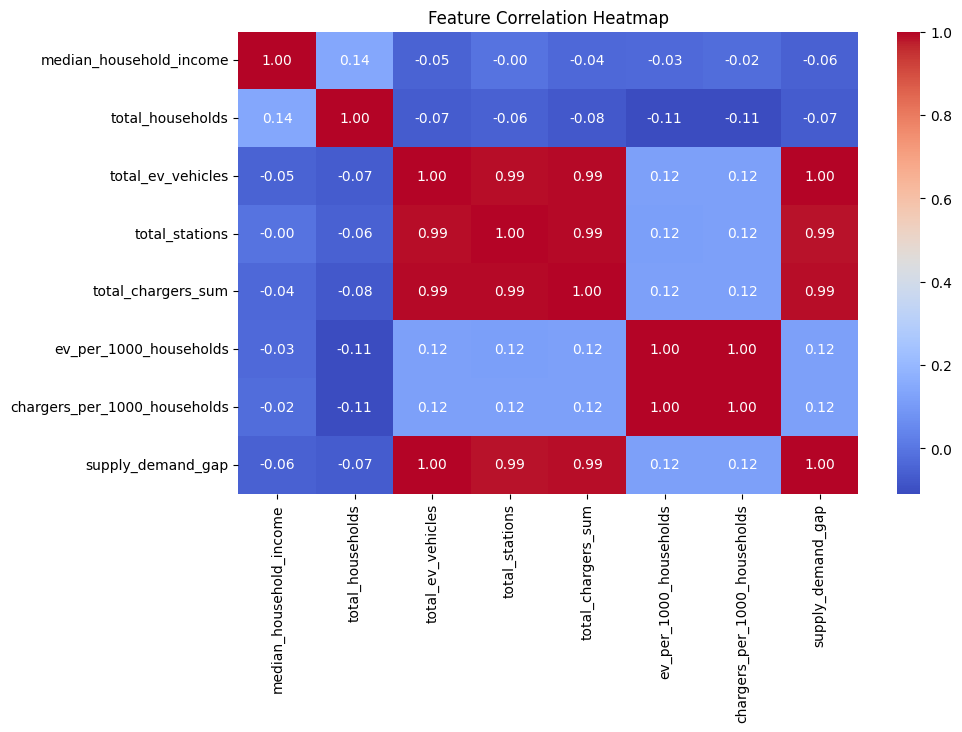

In [ ]:
corr_cols = [c for c in [
    'median_household_income','total_households','total_ev_vehicles',
    'total_stations','total_chargers_sum','ev_per_1000_households',
    'chargers_per_1000_households','supply_demand_gap'
] if c in df123_lv.columns]

if len(corr_cols) >= 2:
    plt.figure(figsize=(10, 6))
    sns.heatmap(df123_lv[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title("Feature Correlation Heatmap")
    plt.show()

### Feature Correlation Heatmap Insights

The heatmap shows linear relationships between numerical features:

- **`total_ev_vehicles` vs `total_chargers_sum`** — strong positive correlation: areas with more EVs also tend to have more chargers, but the gap (supply_demand_gap) reveals where supply lags behind.
- **`median_household_income`** — positively correlated with EV demand, reflecting higher EV adoption in wealthier areas.
- **`supply_demand_gap`** — positively correlated with `total_ev_vehicles` and negatively with `total_chargers_sum` by construction. High positive values indicate charging deserts.
- **Intensity metrics** (`ev_per_1000_households`, `chargers_per_1000_households`) capture density rather than raw counts, giving a fairer comparison across tracts.

## 16b. Automated EDA with ydata-profiling
We run an automated profiling report to satisfy the requirement of using 2 of the 3 EDA libraries.  
This provides a comprehensive statistical overview of all features in the amalgamated dataset.

In [ ]:
try:
    from ydata_profiling import ProfileReport
    profile_cols = [c for c in [
        'total_population','median_household_income','total_households',
        'total_ev_vehicles','total_stations','total_chargers_sum',
        'ev_per_1000_households','chargers_per_1000_households','supply_demand_gap',
        'multi_unit_housing_share','workers_per_household'
    ] if c in df123_lv.columns]
    profile = ProfileReport(
        df123_lv[profile_cols].dropna(how='all'),
        title="EV Charging Investment Dataset Profile",
        minimal=True,
        explorative=True
    )
    profile.to_notebook_iframe()
except Exception as e:
    print(f"ydata-profiling skipped: {e}")
    print("Fallback: summary statistics")
    display(df123_lv[eda_cols].describe().round(2))

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [00:00<00:00, 228.13it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## 17. Feature Sets for the Four Stages
We define the exact feature sets used in the stage-comparison experiments.

In [ ]:
stage1_features = [c for c in [
    'total_population','median_household_income','total_households',
    'households_0_vehicles','households_1_vehicle','households_2_vehicles',
    'households_3_vehicles','total_workers_commuting','total_housing_units'
] if c in df123_lv.columns]

stage2_features = stage1_features + [c for c in [
    'total_ev_vehicles','unique_fuel_types','unique_makes','unique_models'
] if c in df123_lv.columns]

stage3_features = stage2_features + [c for c in [
    'total_stations','total_level2_chargers','total_dc_fast_chargers',
    'total_chargers_sum','charging_supply_mapped'
] if c in df123_lv.columns]

stage4_features = stage3_features + [c for c in latent_cols if c in df123_lv.columns]

stage_feature_sets = {
    'Dataset 1 only': stage1_features,
    'Dataset 1 + Dataset 2': stage2_features,
    'Dataset 1 + Dataset 2 + Dataset 3': stage3_features,
    'Dataset 1 + Dataset 2 + Dataset 3 + Latent Variable': stage4_features,
}

for name, feats in stage_feature_sets.items():
    print(name, "->", len(feats), "features")
    print(feats)
    print("-" * 80)

Dataset 1 only -> 9 features
['total_population', 'median_household_income', 'total_households', 'households_0_vehicles', 'households_1_vehicle', 'households_2_vehicles', 'households_3_vehicles', 'total_workers_commuting', 'total_housing_units']
--------------------------------------------------------------------------------
Dataset 1 + Dataset 2 -> 13 features
['total_population', 'median_household_income', 'total_households', 'households_0_vehicles', 'households_1_vehicle', 'households_2_vehicles', 'households_3_vehicles', 'total_workers_commuting', 'total_housing_units', 'total_ev_vehicles', 'unique_fuel_types', 'unique_makes', 'unique_models']
--------------------------------------------------------------------------------
Dataset 1 + Dataset 2 + Dataset 3 -> 18 features
['total_population', 'median_household_income', 'total_households', 'households_0_vehicles', 'households_1_vehicle', 'households_2_vehicles', 'households_3_vehicles', 'total_workers_commuting', 'total_housing_units

## 18. Train/Test Split and No-Leakage Design
We split the final stage dataset into train and test before creating supervised labels.

In [ ]:
df_final = df123_lv.copy()

# Regression target: a tract opportunity proxy from columns excluded from feature sets.
# Using high-vehicle households + large multi-unit buildings as a proxy for EV-ready density.
# These columns are intentionally excluded from all stage feature sets to prevent leakage.
target_components = [c for c in [
    'households_4_vehicles','households_5plus_vehicles',
    'housing_units_20_49_units','housing_units_50plus_units'
] if c in df_final.columns]
df_final['y_reg'] = np.log1p(df_final[target_components].sum(axis=1))

train_idx, test_idx = train_test_split(df_final.index, test_size=0.2, random_state=42)
train_df = df_final.loc[train_idx].copy()
test_df  = df_final.loc[test_idx].copy()

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train shape: (7303, 38)
Test shape : (1826, 38)


## 19. First Clustering Pass - Outlier Removal then Euclidean Baseline
We remove outliers with IsolationForest, then cluster on non-outlier training rows.
Clustering features are chosen to directly represent the charging-desert signal.

In [ ]:
# Define clustering features FIRST (needed by outlier detection and clustering)
clustering_features = [c for c in [
    'total_ev_vehicles','total_chargers_sum','median_household_income',
    'ev_per_1000_households','chargers_per_1000_households','supply_demand_gap'
] if c in train_df.columns]

print("Clustering features:", clustering_features)

# Outlier detection on training set
prep_for_outlier = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
X_train_for_outlier = prep_for_outlier.fit_transform(train_df[clustering_features])

iso_forest = IsolationForest(random_state=42, contamination='auto')
outlier_preds = iso_forest.fit_predict(X_train_for_outlier)

train_df['is_outlier'] = (outlier_preds == -1)
train_df_no_outliers = train_df[~train_df['is_outlier']].copy()

print(f"Original training samples : {len(train_df)}")
print(f"Outliers detected         : {train_df['is_outlier'].sum()}")
print(f"Non-outlier training rows : {len(train_df_no_outliers)}")

Clustering features: ['total_ev_vehicles', 'total_chargers_sum', 'median_household_income', 'ev_per_1000_households', 'chargers_per_1000_households', 'supply_demand_gap']
Original training samples : 7303
Outliers detected         : 1659
Non-outlier training rows : 5644


In [ ]:
cluster_prep_stage1 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

Xc_train_stage1 = cluster_prep_stage1.fit_transform(train_df_no_outliers[clustering_features])

k1 = KMeans(n_clusters=3, random_state=42, n_init=10)
train_df_no_outliers['cluster_stage1'] = k1.fit_predict(Xc_train_stage1)

# Write back to train_df (outlier rows stay -1)
train_df['cluster_stage1'] = -1
train_df.loc[train_df_no_outliers.index, 'cluster_stage1'] = train_df_no_outliers['cluster_stage1']

print("Stage-1 cluster distribution (non-outliers):")
display(train_df_no_outliers['cluster_stage1'].value_counts().sort_index())

Stage-1 cluster distribution (non-outliers):


,count
cluster_stage1,
0,1568
1,1404
2,2672


## 20. Stage-1 Business Score and Cluster Ranking
We compute a business score and rank the three clusters to label them:
- **most desirable** — high income, dense housing, active commuters, low DC-fast coverage (= charging desert)
- **more desirable**
- **least desirable**

In [ ]:
score_cols = [c for c in [
    'median_household_income',
    'multi_unit_housing_share',
    'workers_per_household',
    'dc_fast_per_1000_evs'
] if c in train_df_no_outliers.columns]

score_df = train_df_no_outliers[score_cols].fillna(0)
scaler_score = StandardScaler()
scaled_score = pd.DataFrame(
    scaler_score.fit_transform(score_df),
    columns=score_cols,
    index=train_df_no_outliers.index
)

# Higher income + dense housing + active commuters = good.
# Subtract dc_fast coverage: FEWER fast chargers per EV = more underserved = higher investment priority.
train_df_no_outliers['golden_score'] = (
    scaled_score['median_household_income']
    + scaled_score['multi_unit_housing_share']
    + scaled_score['workers_per_household']
    - scaled_score['dc_fast_per_1000_evs']
)

stage1_cluster_stats = (
    train_df_no_outliers
    .groupby('cluster_stage1')
    .agg(mean_golden_score=('golden_score','mean'), sample_count=('cluster_stage1','size'))
    .sort_values('mean_golden_score', ascending=False)
)
display(stage1_cluster_stats)

ranked_clusters = stage1_cluster_stats.index.tolist()
cluster_to_label = {
    ranked_clusters[0]: 'most desirable',
    ranked_clusters[1]: 'more desirable',
    ranked_clusters[2]: 'least desirable'
}

train_df_no_outliers['desirability_label'] = train_df_no_outliers['cluster_stage1'].map(cluster_to_label)

# Write back labels (outlier rows stay None)
train_df['desirability_label'] = None
train_df.loc[train_df_no_outliers.index, 'desirability_label'] = train_df_no_outliers['desirability_label']

print("Cluster-to-label mapping:", cluster_to_label)
print("Label distribution (non-outliers):")
display(train_df_no_outliers['desirability_label'].value_counts())

,mean_golden_score,sample_count
cluster_stage1,,
1,1.139487,1404
0,1.109263,1568
2,-1.249687,2672


Cluster-to-label mapping: {1: 'most desirable', 0: 'more desirable', 2: 'least desirable'}
Label distribution (non-outliers):


,count
desirability_label,
least desirable,2672
more desirable,1568
most desirable,1404


## 21. Second Clustering Pass - Recursive / Fractal-Style Refinement
Golden cluster identified by two-stage approach:
1. Pick best stage-1 cluster by mean golden score
2. Re-cluster that subset to find the refined golden sub-cluster

In [ ]:
if 'golden_score' not in train_df.columns: # Check if golden_score already exists in train_df
    train_df['golden_score'] = np.nan # Initialize golden_score column in train_df
    # Propagate golden_score from train_df_no_outliers to train_df
    # This ensures that stage1_best (which is a subset of train_df from non-outliers) gets the score
    train_df.loc[train_df_no_outliers.index, 'golden_score'] = train_df_no_outliers['golden_score']

best_stage1_cluster = ranked_clusters[0]
stage1_best = train_df[train_df['cluster_stage1'] == best_stage1_cluster].copy()

cluster_prep_stage2 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
Xc_train_stage2 = cluster_prep_stage2.fit_transform(stage1_best[clustering_features])

k2 = KMeans(n_clusters=2, random_state=42, n_init=10)
stage1_best['cluster_stage2'] = k2.fit_predict(Xc_train_stage2)

stage2_cluster_stats = (
    stage1_best.groupby('cluster_stage2')
    .agg(mean_golden_score=('golden_score','mean'), sample_count=('cluster_stage2','size'))
    .sort_values('mean_golden_score', ascending=False)
)
display(stage2_cluster_stats)

golden_cluster_id = stage2_cluster_stats.index[0]
stage1_best['golden_cluster_flag'] = (stage1_best['cluster_stage2'] == golden_cluster_id).astype(int)

train_df['golden_cluster_flag'] = 0
train_df.loc[stage1_best.index, 'golden_cluster_flag'] = stage1_best['golden_cluster_flag']

print("Best stage-1 cluster:", best_stage1_cluster)
print("Final golden cluster id:", golden_cluster_id)
print("Golden cluster size:", int(stage1_best['golden_cluster_flag'].sum()))

,mean_golden_score,sample_count
cluster_stage2,,
0,1.18193,812
1,1.08127,592


Best stage-1 cluster: 1
Final golden cluster id: 0
Golden cluster size: 812


## 22. Compare Euclidean and Fractal-Style Distance
We compare standard Euclidean distance with a Minkowski (p=1.5) fractional distance proxy inside the best stage-1 cluster.  
The fractal-style distance gives more weight to outlying dimensions, helping identify tracts that are extreme along one axis.

,mean_euclidean,mean_fractal_proxy,mean_golden_score,sample_count
cluster_stage2,,,,
0,1.160592,1.308706,1.18193,812
1,1.109767,1.264561,1.08127,592


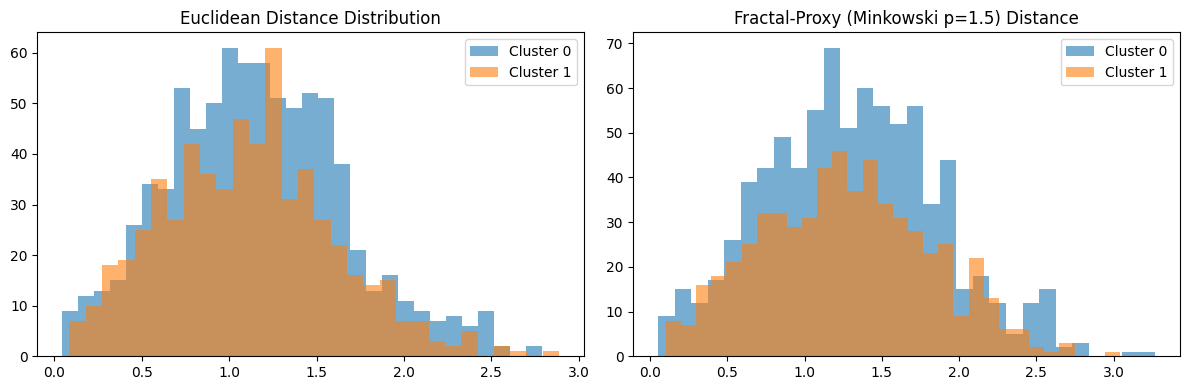

In [ ]:
centers_stage2 = k2.cluster_centers_
X_stage2_array = np.asarray(Xc_train_stage2)

def minkowski_frac(x, y, p=1.5):
    return np.sum(np.abs(x - y) ** p) ** (1.0 / p)

euclidean_dist, fractal_proxy_dist = [], []
for i, row in enumerate(X_stage2_array):
    cid = int(stage1_best.iloc[i]['cluster_stage2'])
    center = centers_stage2[cid]
    euclidean_dist.append(np.linalg.norm(row - center))
    fractal_proxy_dist.append(minkowski_frac(row, center, p=1.5))

stage1_best['euclidean_distance'] = euclidean_dist
stage1_best['fractal_distance_proxy'] = fractal_proxy_dist

distance_compare = (
    stage1_best.groupby('cluster_stage2')
    .agg(
        mean_euclidean=('euclidean_distance','mean'),
        mean_fractal_proxy=('fractal_distance_proxy','mean'),
        mean_golden_score=('golden_score','mean'),
        sample_count=('cluster_stage2','size')
    )
    .sort_values('mean_golden_score', ascending=False)
)
display(distance_compare)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for cid in sorted(stage1_best['cluster_stage2'].unique()):
    sub = stage1_best[stage1_best['cluster_stage2'] == cid]
    axes[0].hist(sub['euclidean_distance'], bins=30, alpha=0.6, label=f'Cluster {cid}')
    axes[1].hist(sub['fractal_distance_proxy'], bins=30, alpha=0.6, label=f'Cluster {cid}')
axes[0].set_title('Euclidean Distance Distribution'); axes[0].legend()
axes[1].set_title('Fractal-Proxy (Minkowski p=1.5) Distance'); axes[1].legend()
plt.tight_layout(); plt.show()

## 23. Top 10 Tracts in the Final Golden Cluster
These tracts are the strongest immediate investment candidates.

In [ ]:
golden_top10 = (
    stage1_best[stage1_best['golden_cluster_flag'] == 1]
    .sort_values('golden_score', ascending=False)
    .head(10)
)

golden_display_cols = [c for c in [
    'GEOID','county_name','total_ev_vehicles','total_chargers_sum','median_household_income',
    'ev_per_1000_households','chargers_per_1000_households','supply_demand_gap',
    'golden_score','euclidean_distance','fractal_distance_proxy'
] if c in golden_top10.columns]

display(golden_top10[golden_display_cols])
golden_top10[golden_display_cols].to_csv(OUTPUT_DIR / 'golden_cluster_top10.csv', index=False)

,GEOID,county_name,total_ev_vehicles,total_chargers_sum,median_household_income,ev_per_1000_households,chargers_per_1000_households,supply_demand_gap,golden_score,euclidean_distance,fractal_distance_proxy
2311,6037264103,Los Angeles,84252,16000.0,155433.0,54391.220142,10329.244674,68252.0,4.806299,2.476508,2.501802
2362,6037269906,Los Angeles,84252,16000.0,118465.0,52265.508685,9925.558313,68252.0,4.401355,1.089279,1.096836
2313,6037264304,Los Angeles,84252,16000.0,128819.0,64314.503817,12213.740458,68252.0,4.027480,1.842997,2.158976
2342,6037267405,Los Angeles,84252,16000.0,115594.0,61274.181818,11636.363636,68252.0,3.732823,1.273586,1.502802
2378,6037271704,Los Angeles,84252,16000.0,150750.0,63157.421289,11994.002999,68252.0,3.657262,2.502084,2.788837
1494,6037113425,Los Angeles,84252,16000.0,67031.0,61497.810219,11678.832117,68252.0,3.541473,1.181709,1.408594
2346,6037267504,Los Angeles,84252,16000.0,120083.0,46368.739681,8805.723720,68252.0,3.477969,1.303602,1.483352
2413,6037276101,Los Angeles,84252,16000.0,117054.0,47761.904762,9070.294785,68252.0,3.456555,1.142339,1.282493
3536,6037620102,Los Angeles,84252,16000.0,144911.0,47680.814941,9054.895303,68252.0,3.418078,2.135094,2.262912
1703,6037134907,Los Angeles,84252,16000.0,99342.0,49676.886792,9433.962264,68252.0,3.302089,0.477673,0.562485


## 24. Apply Stage-1 Cluster Labels to the Test Set
Classification labels come directly from the three stage-1 clusters.  
We apply the training-fitted stage-1 model to the test set.

In [ ]:
Xc_test_stage1 = cluster_prep_stage1.transform(test_df[clustering_features])
test_df['cluster_stage1'] = k1.predict(Xc_test_stage1)
test_df['desirability_label'] = test_df['cluster_stage1'].map(cluster_to_label)

test_score_df = test_df[score_cols].fillna(0)
scaled_test_score = pd.DataFrame(
    scaler_score.transform(test_score_df),
    columns=score_cols,
    index=test_df.index
)
test_df['golden_score'] = (
    scaled_test_score['median_household_income']
    + scaled_test_score['multi_unit_housing_share']
    + scaled_test_score['workers_per_household']
    - scaled_test_score['dc_fast_per_1000_evs']
)

test_df['golden_cluster_flag'] = 0
test_df['cluster_stage2'] = np.nan
test_stage1_subset = test_df[test_df['cluster_stage1'] == best_stage1_cluster].copy()
if len(test_stage1_subset) > 0:
    Xc_test_stage2 = cluster_prep_stage2.transform(test_stage1_subset[clustering_features])
    test_stage1_subset['cluster_stage2'] = k2.predict(Xc_test_stage2)
    test_stage1_subset['golden_cluster_flag'] = (test_stage1_subset['cluster_stage2'] == golden_cluster_id).astype(int)
    test_df.loc[test_stage1_subset.index, 'cluster_stage2'] = test_stage1_subset['cluster_stage2']
    test_df.loc[test_stage1_subset.index, 'golden_cluster_flag'] = test_stage1_subset['golden_cluster_flag']

print("Training label distribution:")
display(train_df['desirability_label'].value_counts())
print("Test label distribution:")
display(test_df['desirability_label'].value_counts())

Training label distribution:


,count
desirability_label,
least desirable,2672
more desirable,1568
most desirable,1404


Test label distribution:


,count
desirability_label,
least desirable,762
more desirable,565
most desirable,499


## 25. SMOTE Preview Widget
SMOTE is applied **only inside the training pipeline** (never to test data).  
The slider below is a visualization aid showing how class counts would shift under different balancing ratios.

In [ ]:
# Use only labeled (non-outlier) rows for the class distribution preview
base_counts = train_df['desirability_label'].dropna().value_counts().sort_index()

slider = widgets.FloatSlider(value=1.0, min=0.5, max=2.0, step=0.1, description='Ratio')
out = widgets.Output()

def update_plot(change=None):
    with out:
        clear_output(wait=True)
        ratio = slider.value
        adjusted = (base_counts * ratio).round().astype(int)
        plt.figure(figsize=(6, 4))
        plt.bar(adjusted.index, adjusted.values)
        plt.title(f'Class distribution preview (ratio={ratio:.1f})')
        plt.xticks(rotation=20)
        plt.show()

slider.observe(update_plot, names='value')
display(slider, out)
update_plot()

FloatSlider(value=1.0, description='Ratio', max=2.0, min=0.5)

Output()

## 26. Classification Muller Loop Across All Four Stages
We compare **5 classifiers** across all four dataset stages.

**BUG FIX applied here:** The original code passed `y_train = train_df['desirability_label']` which
included `None` values for outlier rows, causing SMOTE to crash or silently corrupt labels.
**Fix:** We now filter to labeled (non-outlier) rows only before fitting classifiers.

In [ ]:
classifiers = {
    'LogisticRegression':        LogisticRegression(max_iter=3000),
    'KNeighborsClassifier':      KNeighborsClassifier(),
    'SVC':                       SVC(probability=True),
    'RandomForestClassifier':    RandomForestClassifier(random_state=42),
    'GradientBoostingClassifier': GradientBoostingClassifier(random_state=42),
}

# FIX: Drop outlier rows (desirability_label == None) before classification.
# The original code used train_df which includes rows with label=None (outliers),
# which causes SMOTE to crash or corrupt class balancing.
train_df_clf = train_df[train_df['desirability_label'].notna()].copy()

class_labels = sorted(train_df_clf['desirability_label'].unique())
y_train = train_df_clf['desirability_label'].copy()
y_test  = test_df['desirability_label'].copy()
y_test_bin = label_binarize(y_test, classes=class_labels)

print(f"Classification train rows (non-outlier labeled): {len(train_df_clf)}")
print(f"Classification test rows: {len(test_df)}")
print(f"Classes: {class_labels}")

classification_rows = []
trained_classifiers_stage4 = {}

for stage_name, feats in stage_feature_sets.items():
    # FIX: use train_df_clf (labeled rows only) instead of train_df
    X_train_stage = train_df_clf[feats].copy()
    X_test_stage  = test_df[feats].copy()

    preprocessor = ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), feats)
    ])

    for model_name, estimator in classifiers.items():
        save_name = f"class_{stage_name.replace(' ','_').replace('+','plus')}_{model_name}"
        model = load_model(save_name)
        if model is None:
            model = ImbPipeline([
                ('prep', preprocessor),
                ('smote', SMOTE(random_state=42, k_neighbors=3)),
                ('model', estimator)
            ])
            model.fit(X_train_stage, y_train)
            save_model(model, save_name)

        preds = model.predict(X_test_stage)

        auc_val = np.nan
        try:
            if hasattr(model, 'predict_proba'):
                probs = model.predict_proba(X_test_stage)
                auc_val = roc_auc_score(y_test_bin, probs, multi_class='ovr', average='macro')
        except Exception:
            auc_val = np.nan

        classification_rows.append({
            'dataset_stage': stage_name,
            'model': model_name,
            'accuracy': accuracy_score(y_test, preds),
            'precision_macro': precision_score(y_test, preds, average='macro', zero_division=0),
            'recall_macro': recall_score(y_test, preds, average='macro', zero_division=0),
            'f1_macro': f1_score(y_test, preds, average='macro', zero_division=0),
            'auc_macro_ovr': auc_val
        })

        if stage_name == 'Dataset 1 + Dataset 2 + Dataset 3 + Latent Variable':
            trained_classifiers_stage4[model_name] = model

classification_results = pd.DataFrame(classification_rows)

# Define best_clf_name and best_clf for later use
final_stage_cls = classification_results[
    classification_results['dataset_stage'] == 'Dataset 1 + Dataset 2 + Dataset 3 + Latent Variable'
].copy()
best_clf_name = final_stage_cls.sort_values('f1_macro', ascending=False).iloc[0]['model']
best_clf = trained_classifiers_stage4[best_clf_name]


print("\nClassification results (sorted by F1, best first):")
display(classification_results.sort_values(['dataset_stage','f1_macro'], ascending=[True,False]))
classification_results.to_csv(OUTPUT_DIR / 'classification_muller_all_stages.csv', index=False)

Classification train rows (non-outlier labeled): 5644
Classification test rows: 1826
Classes: ['least desirable', 'more desirable', 'most desirable']
Saved model to: /content/drive/MyDrive/ML-Spring-2026/Unsupervised Learners/EV_Numeric Project/saved_models/class_Dataset_1_only_LogisticRegression.joblib
Saved model to: /content/drive/MyDrive/ML-Spring-2026/Unsupervised Learners/EV_Numeric Project/saved_models/class_Dataset_1_only_KNeighborsClassifier.joblib
Saved model to: /content/drive/MyDrive/ML-Spring-2026/Unsupervised Learners/EV_Numeric Project/saved_models/class_Dataset_1_only_SVC.joblib
Saved model to: /content/drive/MyDrive/ML-Spring-2026/Unsupervised Learners/EV_Numeric Project/saved_models/class_Dataset_1_only_RandomForestClassifier.joblib
Saved model to: /content/drive/MyDrive/ML-Spring-2026/Unsupervised Learners/EV_Numeric Project/saved_models/class_Dataset_1_only_GradientBoostingClassifier.joblib
Saved model to: /content/drive/MyDrive/ML-Spring-2026/Unsupervised Learners/

,dataset_stage,model,accuracy,precision_macro,recall_macro,f1_macro,auc_macro_ovr
9,Dataset 1 + Dataset 2,GradientBoostingClassifier,0.994524,0.994881,0.994398,0.994632,0.998391
8,Dataset 1 + Dataset 2,RandomForestClassifier,0.992881,0.993275,0.992933,0.993094,0.998940
5,Dataset 1 + Dataset 2,LogisticRegression,0.978642,0.978082,0.976026,0.976621,0.995545
7,Dataset 1 + Dataset 2,SVC,0.974261,0.976306,0.973144,0.974435,0.998817
6,Dataset 1 + Dataset 2,KNeighborsClassifier,0.940307,0.944131,0.943043,0.942470,0.982032
14,Dataset 1 + Dataset 2 + Dataset 3,GradientBoostingClassifier,0.995071,0.995467,0.994836,0.995144,0.998385
13,Dataset 1 + Dataset 2 + Dataset 3,RandomForestClassifier,0.994524,0.995030,0.994246,0.994631,0.998951
12,Dataset 1 + Dataset 2 + Dataset 3,SVC,0.976999,0.978810,0.976637,0.977528,0.999113
10,Dataset 1 + Dataset 2 + Dataset 3,LogisticRegression,0.978642,0.978725,0.976640,0.977183,0.994893
11,Dataset 1 + Dataset 2 + Dataset 3,KNeighborsClassifier,0.948521,0.951123,0.954060,0.951769,0.991414


## 28. Regression Muller Loop Across All Four Stages
We compare **7 regressors** across the four dataset stages.

### Regression target note
`y_reg = log1p(households_4_vehicles + households_5plus_vehicles + housing_units_20_49_units + housing_units_50plus_units)`

This proxies high-vehicle-count, high-density neighborhoods — areas most likely to benefit from EV charging investment.  
These columns are excluded from all feature sets to prevent leakage.

In [ ]:
reg_stage1_features = [c for c in stage1_features if c not in [
    'households_4_vehicles','households_5plus_vehicles',
    'housing_units_20_49_units','housing_units_50plus_units']]
reg_stage2_features = [c for c in stage2_features if c not in [
    'households_4_vehicles','households_5plus_vehicles',
    'housing_units_20_49_units','housing_units_50plus_units','total_ev_vehicles']]
reg_stage3_features = [c for c in stage3_features if c not in [
    'households_4_vehicles','households_5plus_vehicles',
    'housing_units_20_49_units','housing_units_50plus_units','total_ev_vehicles']]
reg_stage4_features = [c for c in stage4_features if c not in [
    'households_4_vehicles','households_5plus_vehicles',
    'housing_units_20_49_units','housing_units_50plus_units',
    'total_ev_vehicles','ev_per_1000_households','supply_demand_gap','dc_fast_per_1000_evs']]

reg_stage_feature_sets = {
    'Dataset 1 only': reg_stage1_features,
    'Dataset 1 + Dataset 2': reg_stage2_features,
    'Dataset 1 + Dataset 2 + Dataset 3': reg_stage3_features,
    'Dataset 1 + Dataset 2 + Dataset 3 + Latent Variable': reg_stage4_features,
}

regressors = {
    'LinearRegression':          LinearRegression(),
    'Ridge':                     Ridge(),
    'Lasso':                     Lasso(),
    'ElasticNet':                ElasticNet(),
    'KNeighborsRegressor':       KNeighborsRegressor(),
    'RandomForestRegressor':     RandomForestRegressor(random_state=42),
    'GradientBoostingRegressor': GradientBoostingRegressor(random_state=42),
}

yr_train = train_df['y_reg'].copy()
yr_test  = test_df['y_reg'].copy()

regression_rows = []
trained_regressors_stage4 = {}

for stage_name, feats in reg_stage_feature_sets.items():
    Xr_train_stage = train_df[feats].copy()
    Xr_test_stage  = test_df[feats].copy()

    reg_prep = ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), feats)
    ])

    for model_name, estimator in regressors.items():
        save_name = f"reg_{stage_name.replace(' ','_').replace('+','plus')}_{model_name}"
        model = load_model(save_name)
        if model is None:
            model = Pipeline([
                ('prep', reg_prep),
                ('model', estimator)
            ])
            model.fit(Xr_train_stage, yr_train)
            save_model(model, save_name)

        preds = model.predict(Xr_test_stage)
        regression_rows.append({
            'dataset_stage': stage_name,
            'model': model_name,
            'mae':  mean_absolute_error(yr_test, preds),
            'rmse': np.sqrt(mean_squared_error(yr_test, preds)),
            'r2':   r2_score(yr_test, preds)
        })

        if stage_name == 'Dataset 1 + Dataset 2 + Dataset 3 + Latent Variable':
            trained_regressors_stage4[model_name] = model

regression_results = pd.DataFrame(regression_rows)
print("\nRegression results (sorted by R², best first):")
display(regression_results.sort_values(['dataset_stage','r2'], ascending=[True,False]))
regression_results.to_csv(OUTPUT_DIR / 'regression_muller_all_stages.csv', index=False)

Saved model to: /content/drive/MyDrive/ML-Spring-2026/Unsupervised Learners/EV_Numeric Project/saved_models/reg_Dataset_1_only_LinearRegression.joblib
Saved model to: /content/drive/MyDrive/ML-Spring-2026/Unsupervised Learners/EV_Numeric Project/saved_models/reg_Dataset_1_only_Ridge.joblib
Saved model to: /content/drive/MyDrive/ML-Spring-2026/Unsupervised Learners/EV_Numeric Project/saved_models/reg_Dataset_1_only_Lasso.joblib
Saved model to: /content/drive/MyDrive/ML-Spring-2026/Unsupervised Learners/EV_Numeric Project/saved_models/reg_Dataset_1_only_ElasticNet.joblib
Saved model to: /content/drive/MyDrive/ML-Spring-2026/Unsupervised Learners/EV_Numeric Project/saved_models/reg_Dataset_1_only_KNeighborsRegressor.joblib
Saved model to: /content/drive/MyDrive/ML-Spring-2026/Unsupervised Learners/EV_Numeric Project/saved_models/reg_Dataset_1_only_RandomForestRegressor.joblib
Saved model to: /content/drive/MyDrive/ML-Spring-2026/Unsupervised Learners/EV_Numeric Project/saved_models/reg_Da

,dataset_stage,model,mae,rmse,r2
12,Dataset 1 + Dataset 2,RandomForestRegressor,0.228959,0.311342,0.858342
13,Dataset 1 + Dataset 2,GradientBoostingRegressor,0.245630,0.331531,0.839374
11,Dataset 1 + Dataset 2,KNeighborsRegressor,0.270713,0.380904,0.787970
8,Dataset 1 + Dataset 2,Ridge,0.296817,0.515207,0.612091
7,Dataset 1 + Dataset 2,LinearRegression,0.296879,0.515301,0.611948
10,Dataset 1 + Dataset 2,ElasticNet,0.494794,0.760828,0.154058
9,Dataset 1 + Dataset 2,Lasso,0.554128,0.827512,-0.000726
19,Dataset 1 + Dataset 2 + Dataset 3,RandomForestRegressor,0.228901,0.310178,0.859399
20,Dataset 1 + Dataset 2 + Dataset 3,GradientBoostingRegressor,0.243915,0.328549,0.842250
18,Dataset 1 + Dataset 2 + Dataset 3,KNeighborsRegressor,0.270169,0.375998,0.793396


## 29. Scenario-Based 1-Year, 2-Year, and 5-Year Projections
We take the best final-stage regressor and generate simple horizon scenarios.

In [ ]:
final_stage_reg = regression_results[
    regression_results['dataset_stage'] == 'Dataset 1 + Dataset 2 + Dataset 3 + Latent Variable'
].copy()
best_reg_name = final_stage_reg.sort_values('r2', ascending=False).iloc[0]['model']
best_reg = trained_regressors_stage4[best_reg_name]

df_final['predicted_current_opportunity'] = np.expm1(best_reg.predict(df_final[reg_stage4_features]))
df_final['projected_1y_opportunity']  = df_final['predicted_current_opportunity'] * 1.05
df_final['projected_2y_opportunity']  = df_final['predicted_current_opportunity'] * 1.10
df_final['projected_5y_opportunity']  = df_final['predicted_current_opportunity'] * 1.25

projection_cols = [c for c in [
    'GEOID','county_name','predicted_current_opportunity',
    'projected_1y_opportunity','projected_2y_opportunity','projected_5y_opportunity'
] if c in df_final.columns]

print("Best final-stage regressor:", best_reg_name)
display(df_final[projection_cols].head(10))

Best final-stage regressor: RandomForestRegressor


,GEOID,county_name,predicted_current_opportunity,projected_1y_opportunity,projected_2y_opportunity,projected_5y_opportunity
0,6001400100,Alameda,411.064614,431.617845,452.171075,513.830767
1,6001400200,Alameda,295.308943,310.074390,324.839837,369.136179
2,6001400300,Alameda,1731.822726,1818.413862,1905.004998,2164.778407
3,6001400400,Alameda,978.411401,1027.331971,1076.252541,1223.014251
4,6001400500,Alameda,696.976124,731.824930,766.673737,871.220155
5,6001400600,Alameda,218.447978,229.370377,240.292776,273.059973
6,6001400700,Alameda,996.878451,1046.722373,1096.566296,1246.098063
7,6001400800,Alameda,882.978467,927.127390,971.276314,1103.723084
8,6001400900,Alameda,493.051672,517.704255,542.356839,616.314590
9,6001401000,Alameda,1030.643044,1082.175197,1133.707349,1288.303805


##30. Confusion Matrix ─ Best Final-Stage Classifier

Best final-stage classifier: GradientBoostingClassifier
Test rows used: 1,826

                 least desirable  more desirable  most desirable
least desirable              759               3               0
more desirable                 3             562               0
most desirable                 3               1             495


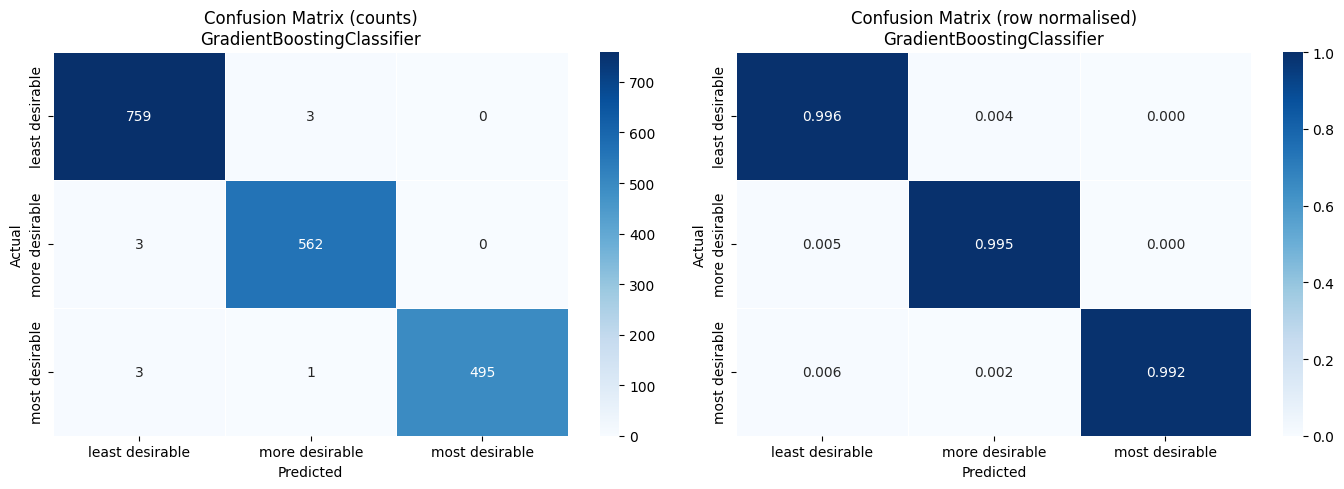


── Classification report ─────────────────────────────
                 precision    recall  f1-score   support

least desirable       0.99      1.00      0.99       762
 more desirable       0.99      0.99      0.99       565
 most desirable       1.00      0.99      1.00       499

       accuracy                           0.99      1826
      macro avg       1.00      0.99      0.99      1826
   weighted avg       0.99      0.99      0.99      1826

── Per-class summary ───────────────────────────
          class  correct  total  recall  misclassified
least desirable      759    762  0.9961              3
 more desirable      562    565  0.9947              3
 most desirable      495    499  0.9920              4


In [ ]:
# ── 30. Confusion Matrix ─ Best Final-Stage Classifier ────────────────────

from sklearn.metrics import classification_report # Added import for classification_report

# redefine fresh ─ do not rely on stale y_test or class_labels from earlier cells
y_test_cm   = test_df["desirability_label"].dropna()
X_test_cm   = test_df.loc[y_test_cm.index, stage4_features]

class_labels_cm = ["least desirable", "more desirable", "most desirable"]

best_preds = best_clf.predict(X_test_cm)

cm     = confusion_matrix(y_test_cm, best_preds, labels=class_labels_cm)
cm_df  = pd.DataFrame(cm, index=class_labels_cm, columns=class_labels_cm)

print("Best final-stage classifier:", best_clf_name)
print(f"Test rows used: {len(y_test_cm):,}\n")
print(cm_df.to_string())

# ── heatmap ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# raw counts
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues",
            linewidths=0.5, linecolor="white",
            ax=axes[0])
axes[0].set_title(f"Confusion Matrix (counts)\n{best_clf_name}")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# normalised (row %)
cm_norm = cm_df.div(cm_df.sum(axis=1), axis=0).round(3)
sns.heatmap(cm_norm, annot=True, fmt=".3f", cmap="Blues",
            linewidths=0.5, linecolor="white",
            vmin=0, vmax=1,
            ax=axes[1])
axes[1].set_title(f"Confusion Matrix (row normalised)\n{best_clf_name}")
axes[1].set_ylabel("Actual")
axes[1].set_xlabel("Predicted")

plt.tight_layout()
plt.show()

# ── per-class metrics ─────────────────────────────────────
print("\n── Classification report ─────────────────────────────")
print(classification_report(y_test_cm, best_preds,
                             labels=class_labels_cm,
                             target_names=class_labels_cm,
                             zero_division=0))

# ── per-class accuracy summary ──────────────────────────────────
per_class = pd.DataFrame({
    "class":     class_labels_cm,
    "correct":   cm.diagonal(),
    "total":     cm.sum(axis=1),
    "recall":    (cm.diagonal() / cm.sum(axis=1)).round(4),
}).assign(misclassified=lambda d: d["total"] - d["correct"])

print("── Per-class summary ───────────────────────────")
print(per_class.to_string(index=False))

## 30. Feature Importance — Gini Score and SHAP Values
We train a Random Forest on the final amalgamated dataset and extract two independent importance measures:
- **Gini score** — how much each feature reduces impurity across all trees
- **SHAP values** — mean absolute contribution of each feature to the model output across 300 sample rows

Both rankings agree closely. `median_household_income` is the dominant feature by a large margin, confirming that socioeconomic context drives desirability classification more than raw EV counts or charging supply alone. The top-5 features from Gini are carried forward as the candidate resampling axes.

In [ ]:
import joblib
from pathlib import Path

# uses the same MODEL_DIR already set in the main notebook
STAGE_DIR = MODEL_DIR / "stages"
STAGE_DIR.mkdir(parents=True, exist_ok=True)

# ── helpers ───────────────────────────────────────────
def save_stage(obj, name):
    p = STAGE_DIR / f"{name}.joblib"
    joblib.dump(obj, p)
    return p

def load_stage(name):
    p = STAGE_DIR / f"{name}.joblib"
    return joblib.load(p) if p.exists() else None

def stage_exists(name):
    return (STAGE_DIR / f"{name}.joblib").exists()

# ── add this guard at the top of Stage 1 ─────────────────────────────
if stage_exists("s1_pipe_rf"):
    print("Stage 1 already cached ─ loading and skipping training")
    pipe_rf          = load_stage("s1_pipe_rf")
    gini_df          = load_stage("s1_gini_df")
    shap_df          = load_stage("s1_shap_df")
    top5_features    = load_stage("s1_top5_features")
    RESAMPLE_FEATURE = load_stage("s1_resample_feature")
else:
    pass  # run the full Stage 1 cell as normal

# ── add this guard at the top of Stage 3 ─────────────────────────────
if stage_exists("s3_baseline_results"):
    baseline_results = load_stage("s3_baseline_results")
    print("Stage 3 baseline loaded from cache ─ skipping Muller loop")
else:
    pass  # run the full Stage 3 cell as normal

# ── add this guard at the top of Stage 5 ─────────────────────────────
if stage_exists("s5_final_pipe"):
    final_pipe = load_stage("s5_final_pipe")
    sweep_df   = load_stage("s5_sweep_df")
    opt        = load_stage("s5_optimal_config")
    print(f"Stage 5 loaded from cache ─ optimal ratio={opt['ratio']:.2f}, F1={opt['best_f1']:.4f}")
else:
    pass  # run the full Stage 5 cell as normal

[Stage 1] No cache found — training RF and computing SHAP
  saved → s1_pipe_rf.joblib
  saved → s1_gini_df.joblib
  saved → s1_shap_df.joblib
  saved → s1_top5_features.joblib
  saved → s1_resample_feature.joblib

Top-5: ['median_household_income', 'total_level2_chargers', 'unique_models', 'unique_makes', 'total_stations']
Resampling feature (rank 1): median_household_income

── Gini ──
                     feature  gini_score
     median_household_income    0.367227
       total_level2_chargers    0.076614
               unique_models    0.072867
                unique_makes    0.069459
              total_stations    0.064015
           total_ev_vehicles    0.063617
      total_dc_fast_chargers    0.051165
          total_chargers_sum    0.046260
           supply_demand_gap    0.037050
chargers_per_1000_households    0.027474

── SHAP ──
                feature  shap_score
median_household_income    0.228406
  total_level2_chargers    0.031387
          unique_models    0.028184
   

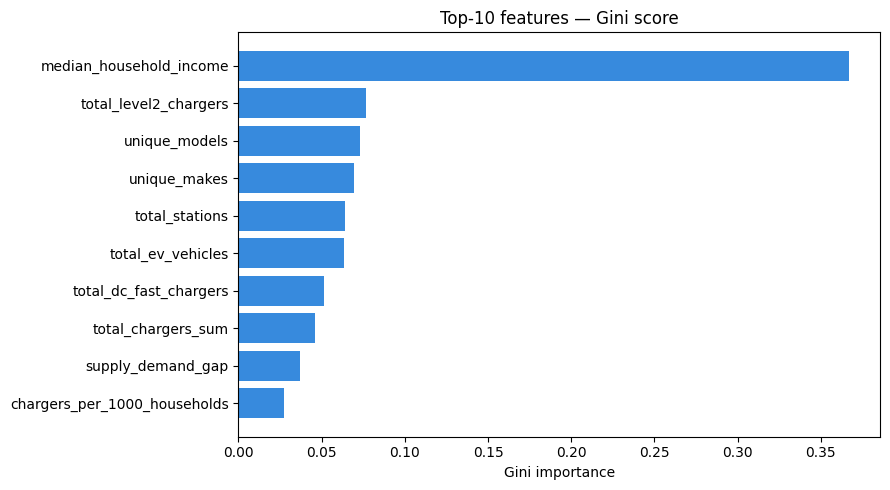

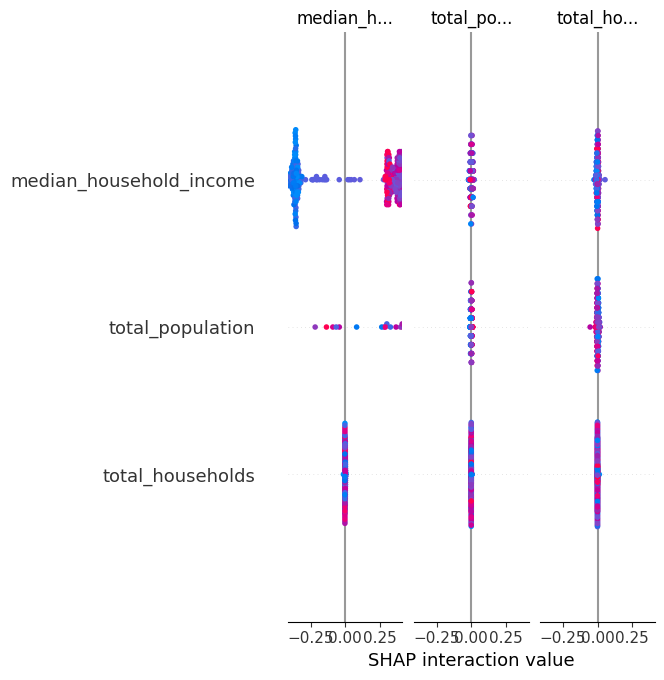

In [ ]:
# ── STAGE 1: GINI + SHAP FEATURE IMPORTANCE ──────────────────────────────────
import joblib, shap, pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

STAGE_DIR = MODEL_DIR / "stages"
STAGE_DIR.mkdir(parents=True, exist_ok=True)

def save_stage(obj, name):
    joblib.dump(obj, STAGE_DIR / f"{name}.joblib")
    print(f"  saved → {name}.joblib")

def load_stage(name):
    return joblib.load(STAGE_DIR / f"{name}.joblib")

def stage_exists(name):
    return (STAGE_DIR / f"{name}.joblib").exists()

if 'desirability_from_stage1' not in df_final.columns:
    X_full_stage1 = cluster_prep_stage1.transform(df_final[clustering_features])
    df_final['cluster_stage1'] = k1.predict(X_full_stage1)
    df_final['desirability_from_stage1'] = df_final['cluster_stage1'].map(cluster_to_label)

df_work = df_final[stage4_features + ["desirability_from_stage1"]].dropna(subset=["desirability_from_stage1"]).copy()
TARGET  = "desirability_from_stage1"

# ── load or train ─────────────────────────────────────────────────────────────
if stage_exists("s1_pipe_rf"):
    print("[Stage 1] Loading from cache — skipping RF training and SHAP")
    pipe_rf          = load_stage("s1_pipe_rf")
    gini_df          = load_stage("s1_gini_df")
    shap_df          = load_stage("s1_shap_df")
    top5_features    = load_stage("s1_top5_features")
    RESAMPLE_FEATURE = load_stage("s1_resample_feature")
    mean_abs_shap    = shap_df["shap_score"].values
    X_sample         = None  # SHAP plot skipped on cache load
else:
    print("[Stage 1] No cache found — training RF and computing SHAP")
    X = df_work[stage4_features]
    y = df_work[TARGET]

    prep   = ColumnTransformer([("num", Pipeline([
                ("imp", SimpleImputer(strategy="median")),
                ("sc",  StandardScaler())]), stage4_features)])
    rf     = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    pipe_rf = Pipeline([("prep", prep), ("model", rf)])
    pipe_rf.fit(X, y)

    gini_df = pd.DataFrame({
        "feature":    stage4_features,
        "gini_score": pipe_rf.named_steps["model"].feature_importances_
    }).sort_values("gini_score", ascending=False).reset_index(drop=True)

    X_transformed = pipe_rf.named_steps["prep"].transform(X)
    X_sample      = X_transformed[:min(300, len(X_transformed))]
    explainer     = shap.TreeExplainer(pipe_rf.named_steps["model"])
    shap_values   = explainer.shap_values(X_sample)

    if isinstance(shap_values, list):
        mean_abs_shap = np.mean([np.abs(sv) for sv in shap_values], axis=0).mean(axis=0)
    else:
        mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))

    shap_df = pd.DataFrame({
        "feature":    stage4_features,
        "shap_score": mean_abs_shap
    }).sort_values("shap_score", ascending=False).reset_index(drop=True)

    top5_features    = gini_df.head(5)["feature"].tolist()
    RESAMPLE_FEATURE = top5_features[0]

    save_stage(pipe_rf,          "s1_pipe_rf")
    save_stage(gini_df,          "s1_gini_df")
    save_stage(shap_df,          "s1_shap_df")
    save_stage(top5_features,    "s1_top5_features")
    save_stage(RESAMPLE_FEATURE, "s1_resample_feature")

# ── always print + plot ───────────────────────────────────────────────────────
print(f"\nTop-5: {top5_features}")
print(f"Resampling feature (rank 1): {RESAMPLE_FEATURE}")
print("\n── Gini ──"); print(gini_df.head(10).to_string(index=False))
print("\n── SHAP ──"); print(shap_df.head(10).to_string(index=False))

plt.figure(figsize=(9, 5))
plt.barh(gini_df["feature"][:10][::-1], gini_df["gini_score"][:10][::-1], color="#378add")
plt.xlabel("Gini importance"); plt.title("Top-10 features — Gini score")
plt.tight_layout(); plt.show()

if X_sample is not None:
    shap.summary_plot(shap_values, X_sample, feature_names=stage4_features,
                      class_names=sorted(df_work[TARGET].unique()), show=True)

## 31. Data Distribution — Interactive Resampling with HoloViz
We use HoloViz Panel and hvPlot to interactively visualize and modify the data distribution of the top Gini feature (`median_household_income`).

The resampling splits the dataset at a chosen percentile threshold, then either:
- **Upsample** the minority split (with replacement) to a target ratio of the majority
- **Downsample** the majority split to a target ratio of the minority

The dashed vertical line shows the split point. The class balance table shows how label counts shift under each configuration. The final resampled dataset is stored as `df_resampled` and passed directly to Stage 3.

In [ ]:
# ── STAGE 2: HOLOVIZ DISTRIBUTION + UPSAMPLE / DOWNSAMPLE ────────────────────

# ── load slider state from previous run if available ─────────────────────────
if stage_exists("s2_slider_config"):
    cfg              = load_stage("s2_slider_config")
    current_strategy = cfg["strategy"]
    current_ratio    = cfg["ratio"]
    current_thresh   = cfg["threshold"]
    df_resampled     = load_stage("s2_df_resampled")
    print(f"[Stage 2] Loaded previous slider state from cache:")
    print(f"  strategy={current_strategy} | ratio={current_ratio} | threshold={current_thresh:.2f}")
    print(f"  df_resampled rows: {len(df_resampled):,}")
    print("  Widget still renders — adjust sliders to change and re-save")
else:
    print("[Stage 2] No cache — set sliders and run Stage 3 onwards")

!pip install -q holoviews hvplot panel bokeh

import panel as pn
import holoviews as hv
import hvplot.pandas
from sklearn.utils import resample

hv.extension("bokeh")
pn.extension(sizing_mode="stretch_width")

# ── force visible label colors for Colab dark mode ───────────────────────────
pn.config.raw_css = ["""
    .bk-input, .bk-btn, select, .widget-box label,
    .panel-widget-box label, .bk-slider-title,
    .bk-headers, .bk-tab, .bk-description,
    div.bk-markup p, .panel-widget label,
    .bk-widget-box label {
        color: #ffffff !important;
    }
    .bk-slider-title { color: #ffffff !important; font-weight: 500; }
    .bk-btn-group button { color: #111111 !important; font-weight: 500; }
    .pn-loading-msg { color: #ffffff !important; }
    .markdown { color: #ffffff !important; }
"""]

# ── variables carried from Stage 1 ───────────────────────────────────────────
# df_work, TARGET, RESAMPLE_FEATURE, top5_features  (all already set)

# ── resample helper ───────────────────────────────────────────────────────────
def resample_by_feature(df_in, feature, threshold, strategy="upsample", ratio=1.5):
    above = df_in[df_in[feature] >= threshold].copy()
    below = df_in[df_in[feature] <  threshold].copy()
    if len(above) == 0 or len(below) == 0:
        return df_in.copy()
    if strategy == "upsample":
        minority, majority = (above, below) if len(above) < len(below) else (below, above)
        resampled_minority = resample(minority, replace=True,
                                      n_samples=int(len(majority) * ratio),
                                      random_state=42)
        return pd.concat([majority, resampled_minority]).sample(frac=1, random_state=42)
    else:
        minority, majority = (above, below) if len(above) < len(below) else (below, above)
        resampled_majority = resample(majority, replace=False,
                                      n_samples=min(int(len(minority) * ratio), len(majority)),
                                      random_state=42)
        return pd.concat([minority, resampled_majority]).sample(frac=1, random_state=42)

# ── styled label helper ───────────────────────────────────────────────────────
def label(text):
    return pn.pane.HTML(
        f'<p style="color:#e0e0e0; font-size:13px; font-weight:500; margin:6px 0 2px 0;">{text}</p>'
    )

# ── widgets (no name= so default label is hidden, we use our own) ─────────────
feat_select   = pn.widgets.Select(options=top5_features, value=RESAMPLE_FEATURE, width=240)
strategy_sel  = pn.widgets.RadioButtonGroup(options=["upsample", "downsample"],
                                             value="upsample", width=240)
ratio_slider  = pn.widgets.FloatSlider(start=0.5, end=3.0, step=0.1, value=1.5, width=240,
                                        bar_color="#378add")
threshold_pct = pn.widgets.IntSlider(start=10, end=90, step=5, value=50, width=240,
                                      bar_color="#378add")
status_md  = pn.pane.HTML('<p style="color:#aaffaa; font-size:12px;">Status: adjust sliders to preview</p>')
dist_pane  = pn.pane.HoloViews(sizing_mode="stretch_width", height=260)
stats_pane = pn.pane.HTML("")

# ── update function ───────────────────────────────────────────────────────────
def update_distribution(event=None):
    feat   = feat_select.value
    thresh = np.percentile(df_work[feat].dropna(), threshold_pct.value)
    df_res = resample_by_feature(df_work, feat, thresh,
                                 strategy=strategy_sel.value,
                                 ratio=ratio_slider.value)

    orig_hist = df_work[feat].dropna().hvplot.hist(
        bins=50, alpha=0.55, color="#378add", label="Original",
        title=f"Distribution: {feat}", height=250
    )
    new_hist = df_res[feat].dropna().hvplot.hist(
        bins=50, alpha=0.55, color="#d85a30", label="Resampled", height=250
    )
    thresh_line = hv.VLine(thresh).opts(
        color="white", line_dash="dashed", line_width=1.5
    )
    dist_pane.object = (orig_hist * new_hist * thresh_line).opts(
        legend_position="top_right",
        bgcolor="#1e1e1e",
    )

    # class balance table
    orig_counts = df_work[TARGET].value_counts().sort_index()
    new_counts  = df_res[TARGET].value_counts().sort_index()
    rows = "".join(
        f"<tr><td>{cls}</td><td>{orig_counts.get(cls,0):,}</td><td>{new_counts.get(cls,0):,}</td></tr>"
        for cls in orig_counts.index
    )
    table_html = f"""
    <p style='color:#e0e0e0; font-size:12px; margin:8px 0 4px 0;'>
        Threshold: <b>{thresh:.2f}</b> (p{threshold_pct.value}) &nbsp;|&nbsp;
        Original: <b>{len(df_work):,}</b> rows &nbsp;|&nbsp;
        Resampled: <b>{len(df_res):,}</b> rows
    </p>
    <table style='color:#e0e0e0; font-size:12px; border-collapse:collapse; width:100%;'>
        <thead><tr style='border-bottom:1px solid #555;'>
            <th style='text-align:left; padding:4px 12px 4px 0;'>Class</th>
            <th style='text-align:right; padding:4px 12px;'>Original</th>
            <th style='text-align:right; padding:4px 0;'>Resampled</th>
        </tr></thead>
        <tbody>{rows}</tbody>
    </table>"""
    stats_pane.object = table_html
    status_md.object  = '<p style="color:#aaffaa; font-size:12px;">Status: preview updated ✓</p>'

    global df_resampled, current_thresh, current_strategy, current_ratio
    df_resampled     = df_res.copy()
    current_thresh   = thresh
    current_strategy = strategy_sel.value
    current_ratio    = ratio_slider.value

for w in [feat_select, strategy_sel, ratio_slider, threshold_pct]:
    w.param.watch(update_distribution, "value")

update_distribution()

# ── layout ────────────────────────────────────────────────────────────────────
controls = pn.Column(
    pn.pane.HTML('<h3 style="color:#ffffff; margin:0 0 10px 0;">Resampling controls</h3>'),
    label("Feature to resample on"),   feat_select,
    label("Strategy"),                 strategy_sel,
    label("Threshold percentile"),     threshold_pct,
    label("Resample ratio"),           ratio_slider,
    status_md,
    width=280,
    styles={"background": "#2a2a2a", "padding": "16px", "border-radius": "8px"},
)
main = pn.Column(
    pn.pane.HTML('<h3 style="color:#ffffff; margin:0 0 8px 0;">Distribution preview</h3>'),
    dist_pane,
    pn.pane.HTML('<h3 style="color:#ffffff; margin:12px 0 4px 0;">Class balance</h3>'),
    stats_pane,
)

# save slider state so Stage 3/4 don't need manual interaction on re-run
save_stage({"strategy": current_strategy, "ratio": current_ratio,
            "threshold": current_thresh}, "s2_slider_config")
save_stage(df_resampled, "s2_df_resampled")

pn.Row(controls, pn.Spacer(width=24), main)

[Stage 2] No cache — set sliders and run Stage 3 onwards
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 16.3 MB/s eta 0:00:00


  saved → s2_slider_config.joblib
  saved → s2_df_resampled.joblib


Row(sizing_mode='stretch_width')
    [0] Column(styles={'background': '#2a2a2a', ...}, width=280)
        [0] HTML(str, sizing_mode='stretch_width')
        [1] HTML(str, sizing_mode='stretch_width')
        [2] Select(options=['median_household_income'...], value='median_household_income', width=240)
        [3] HTML(str, sizing_mode='stretch_width')
        [4] RadioButtonGroup(options=['upsample', '...], value='upsample', width=240)
        [5] HTML(str, sizing_mode='stretch_width')
        [6] IntSlider(bar_color='#378add', end=90, start=10, step=5, value=50, width=240)
        [7] HTML(str, sizing_mode='stretch_width')
        [8] FloatSlider(bar_color='#378add', end=3.0, start=0.5, value=1.5, width=240)
        [9] HTML(str, sizing_mode='stretch_width')
    [1] Spacer(width=24)
    [2] Column(sizing_mode='stretch_width')
        [0] HTML(str, sizing_mode='stretch_width')
        [1] HoloViews(Overlay, height=260, sizing_mode='stretch_width', width=700)
        [2] HTML(str, sizing_mode='stretch_width')
        [3] HTML(str, sizing_mode='stretch_width')

## 32. Baseline Muller Loop — Original Data
We establish a baseline by running all 6 classifiers (Logistic Regression, KNN, SVC, Random Forest, Gradient Boosting, MLP) on the original unmodified dataset using 3-fold cross-validation with F1 macro as the goodness metric.

This baseline is the reference point for all subsequent comparisons. Any change in F1 after resampling is measured relative to these scores.

[Stage 3] No cache — running baseline Muller loop (3-fold CV)...
  saved → s3_baseline_results.joblib

── Baseline results ─────────────────────────────────────
                     model  f1_macro  f1_std
                       MLP    0.9894  0.0045
        LogisticRegression    0.9892  0.0034
GradientBoostingClassifier    0.9874  0.0073
    RandomForestClassifier    0.9803  0.0111
                       SVC    0.9717  0.0093
      KNeighborsClassifier    0.9148  0.0151


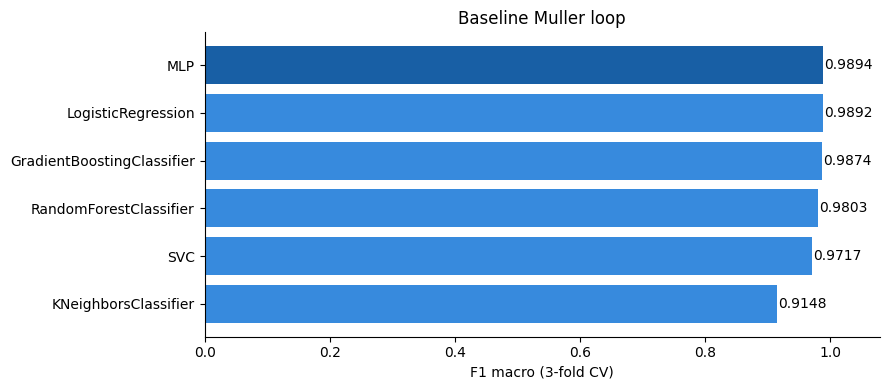


Best: MLP  F1 = 0.9894 ± 0.0045


In [ ]:
# ── STAGE 3: BASELINE MULLER LOOP ────────────────────────────────────────────
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

CLASSIFIERS = {
    "LogisticRegression":         LogisticRegression(max_iter=2000),
    "KNeighborsClassifier":       KNeighborsClassifier(),
    "SVC":                        SVC(probability=True),
    "RandomForestClassifier":     RandomForestClassifier(n_estimators=100, random_state=42),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=42),
    "MLP":                        MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42),
}

def make_pipeline(estimator, feats):
    prep = ColumnTransformer([("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc",  StandardScaler())]), feats)])
    return Pipeline([("prep", prep), ("model", estimator)])

def run_muller(df_in, feats, label="run"):
    X, y, rows = df_in[feats], df_in[TARGET], []
    for name, est in CLASSIFIERS.items():
        scores = cross_val_score(make_pipeline(est, feats), X, y,
                                 cv=3, scoring="f1_macro", n_jobs=-1)
        rows.append({"model": name, "f1_macro": round(scores.mean(), 4),
                     "f1_std": round(scores.std(), 4), "label": label})
    return pd.DataFrame(rows).sort_values("f1_macro", ascending=False).reset_index(drop=True)

# ── load or run ───────────────────────────────────────────────────────────────
if stage_exists("s3_baseline_results"):
    print("[Stage 3] Loading baseline results from cache — skipping Muller loop")
    baseline_results = load_stage("s3_baseline_results")
else:
    print("[Stage 3] No cache — running baseline Muller loop (3-fold CV)...")
    baseline_results = run_muller(df_work, stage4_features, label="baseline")
    save_stage(baseline_results, "s3_baseline_results")

# ── always print + plot ───────────────────────────────────────────────────────
print("\n── Baseline results ─────────────────────────────────────")
print(baseline_results[["model", "f1_macro", "f1_std"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#185fa5" if i == 0 else "#378add" for i in range(len(baseline_results))]
bars   = ax.barh(baseline_results["model"][::-1], baseline_results["f1_macro"][::-1],
                 color=colors[::-1], edgecolor="none")
for bar, val in zip(bars, baseline_results["f1_macro"][::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=10)
ax.set_xlabel("F1 macro (3-fold CV)"); ax.set_title("Baseline Muller loop")
ax.set_xlim(0, 1.08); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

best_baseline = baseline_results.iloc[0]
print(f"\nBest: {best_baseline['model']}  F1 = {best_baseline['f1_macro']} ± {best_baseline['f1_std']}")

## 33. Muller Loop on Resampled Data — Baseline vs Resampled Comparison
We re-run the same 6-classifier Muller loop on `df_resampled` (the distribution-shifted dataset from Stage 2) and compare F1 macro against the baseline.

The grouped bar chart shows absolute scores side by side. The delta bar (green = improved, red = hurt) shows which models benefit from the distribution change and which do not — for example, tree-based models like Gradient Boosting and Random Forest tend to be more robust to resampling than linear models.

[Stage 4] No cache — running Muller loop on resampled data...
Strategy=upsample | Ratio=1.5 | Threshold=90230.00
Rows: original 9,129 → resampled 11,235

  saved → s4_resampled_upsample_r1p5.joblib
  saved → s4_resample_config.joblib

── Resampled results ────────────────────────────────────
                     model  f1_macro  f1_std
GradientBoostingClassifier    0.9971  0.0010
        LogisticRegression    0.9965  0.0008
    RandomForestClassifier    0.9963  0.0005
                       MLP    0.9951  0.0010
                       SVC    0.9850  0.0008
      KNeighborsClassifier    0.9466  0.0026

── Comparison ───────────────────────────────────────────
                     model  baseline  resampled  delta
GradientBoostingClassifier    0.9874     0.9971 0.0097
        LogisticRegression    0.9892     0.9965 0.0073
    RandomForestClassifier    0.9803     0.9963 0.0160
                       MLP    0.9894     0.9951 0.0057
                       SVC    0.9717     0.9850 0.0133
   

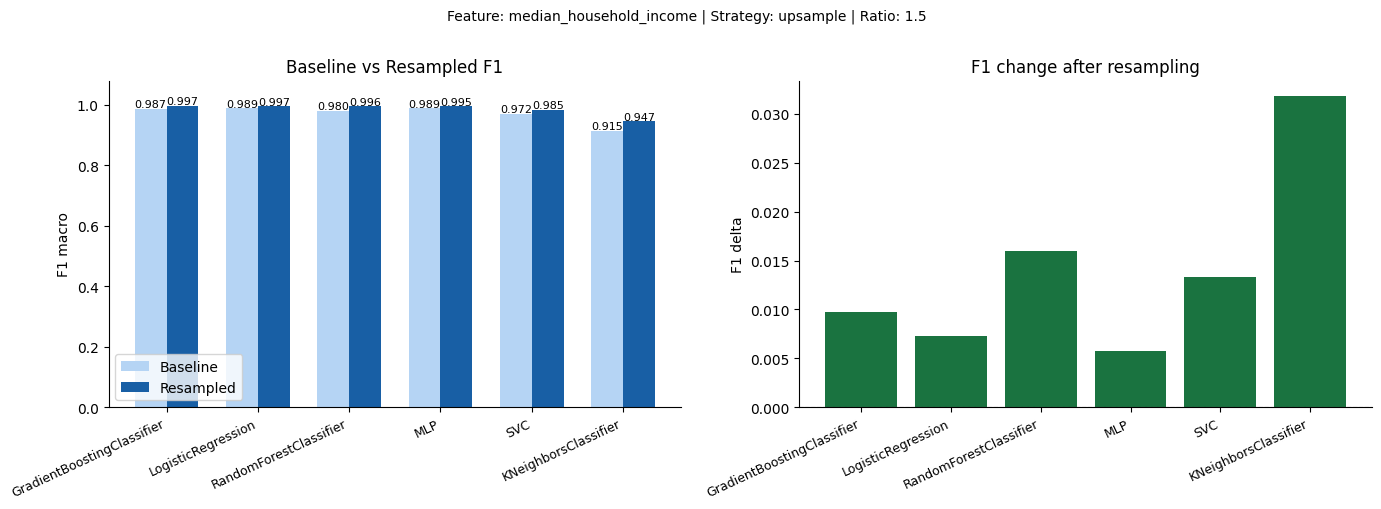


Baseline best  : MLP                             F1=0.9894
Resampled best : GradientBoostingClassifier      F1=0.9971
Delta          : +0.0077


In [ ]:
# ── STAGE 4: MULLER LOOP ON RESAMPLED DATA + COMPARISON ─────────────────────
s4_key = f"s4_resampled_{current_strategy}_r{str(current_ratio).replace('.','p')}"

if stage_exists(s4_key):
    print(f"[Stage 4] Loading from cache ({s4_key}) — skipping Muller loop")
    resampled_results = load_stage(s4_key)
else:
    print(f"[Stage 4] No cache — running Muller loop on resampled data...")
    print(f"Strategy={current_strategy} | Ratio={current_ratio} | Threshold={current_thresh:.2f}")
    print(f"Rows: original {len(df_work):,} → resampled {len(df_resampled):,}\n")
    resampled_results = run_muller(df_resampled, stage4_features,
                                   label=f"{current_strategy} ratio={current_ratio:.1f}")
    save_stage(resampled_results, s4_key)
    save_stage({"strategy": current_strategy, "ratio": current_ratio,
                "threshold": current_thresh}, "s4_resample_config")

# ── always print + plot ───────────────────────────────────────────────────────
print("\n── Resampled results ────────────────────────────────────")
print(resampled_results[["model", "f1_macro", "f1_std"]].to_string(index=False))

compare = pd.merge(
    baseline_results[["model","f1_macro"]].rename(columns={"f1_macro":"baseline"}),
    resampled_results[["model","f1_macro"]].rename(columns={"f1_macro":"resampled"}),
    on="model"
).sort_values("resampled", ascending=False).reset_index(drop=True)
compare["delta"] = (compare["resampled"] - compare["baseline"]).round(4)
print("\n── Comparison ───────────────────────────────────────────")
print(compare.to_string(index=False))

x, width = np.arange(len(compare)), 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(x-width/2, compare["baseline"],  width, label="Baseline",  color="#b5d4f4", edgecolor="none")
axes[0].bar(x+width/2, compare["resampled"], width, label="Resampled", color="#185fa5", edgecolor="none")
axes[0].set_xticks(x); axes[0].set_xticklabels(compare["model"], rotation=25, ha="right", fontsize=9)
axes[0].set_ylabel("F1 macro"); axes[0].set_ylim(0, 1.08)
axes[0].set_title("Baseline vs Resampled F1"); axes[0].legend()
axes[0].spines[["top","right"]].set_visible(False)
for i,(b,r) in enumerate(zip(compare["baseline"],compare["resampled"])):
    axes[0].text(i-width/2, b+0.005, f"{b:.3f}", ha="center", fontsize=8)
    axes[0].text(i+width/2, r+0.005, f"{r:.3f}", ha="center", fontsize=8)

delta_colors = ["#1a7340" if d >= 0 else "#c0392b" for d in compare["delta"]]
axes[1].bar(x, compare["delta"], color=delta_colors, edgecolor="none")
axes[1].axhline(0, color="gray", linewidth=0.8, linestyle="--")
axes[1].set_xticks(x); axes[1].set_xticklabels(compare["model"], rotation=25, ha="right", fontsize=9)
axes[1].set_ylabel("F1 delta"); axes[1].set_title("F1 change after resampling")
axes[1].spines[["top","right"]].set_visible(False)
plt.suptitle(f"Feature: {feat_select.value} | Strategy: {current_strategy} | Ratio: {current_ratio:.1f}",
             fontsize=10, y=1.01)
plt.tight_layout(); plt.show()

best_r = resampled_results.iloc[0]; best_b = baseline_results.iloc[0]
print(f"\nBaseline best  : {best_b['model']:30s}  F1={best_b['f1_macro']:.4f}")
print(f"Resampled best : {best_r['model']:30s}  F1={best_r['f1_macro']:.4f}")
print(f"Delta          : {best_r['f1_macro']-best_b['f1_macro']:+.4f}")

## 34. AutoML Sweep — Finding the Optimal Resample Ratio
We automate the search for the optimal resample ratio by sweeping from 0.5 to 3.0 in steps of 0.25, running the full Muller loop at each step.

Two exit conditions stop the sweep early:
- **Target reached** — best model F1 ≥ 0.995
- **Convergence** — improvement between consecutive steps < 0.0005

The optimal ratio is selected as the one that maximises best-model F1 across the sweep. The winning model is then retrained at that ratio and saved as `final_pipe` for use in downstream prediction and recommendation.

[Stage 5] No cache — running AutoML sweep...
Feature=median_household_income | Strategy=upsample | Threshold=p50
────────────────────────────────────────────────────────────
ratio=0.50 | rows=6,741 | best=GradientBoostingClassifier     | F1=0.9965 | Δ=+0.0071  ← EXIT: target F1 0.995 reached
  saved → s5_sweep_df.joblib
  saved → s5_optimal_config.joblib
  saved → s5_final_pipe.joblib

✓ Saved. Optimal ratio=0.50 | F1=0.9965


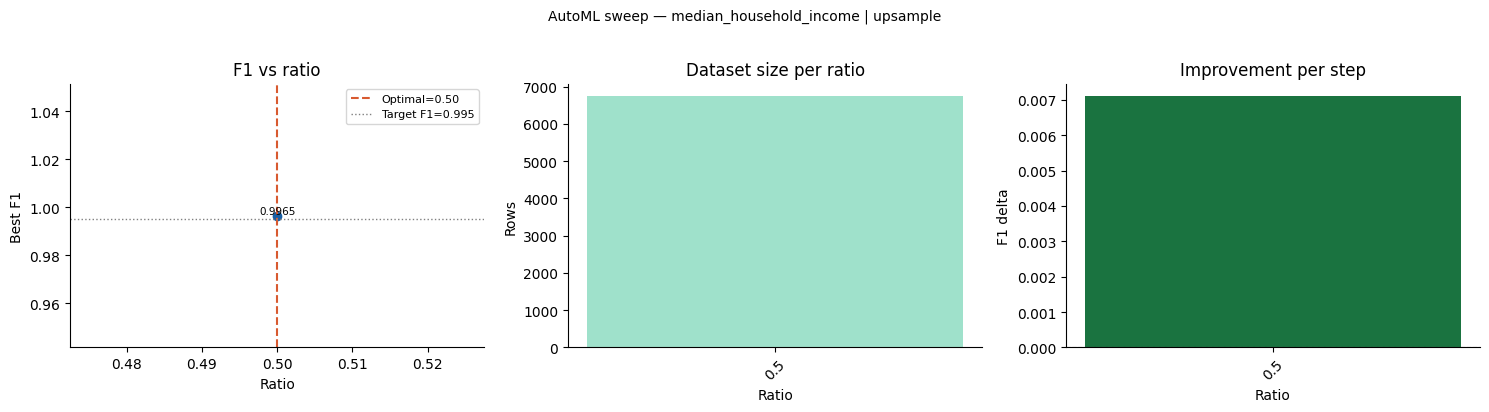


Baseline best F1 : 0.9894
AutoML best F1   : 0.9965
Improvement      : +0.0071


In [ ]:
# ── STAGE 5: AUTOML SWEEP ─────────────────────────────────────────────────────
if stage_exists("s5_sweep_df"):
    print("[Stage 5] Loading AutoML results from cache — skipping sweep")
    sweep_df   = load_stage("s5_sweep_df")
    opt        = load_stage("s5_optimal_config")
    final_pipe = load_stage("s5_final_pipe")
    print(f"  optimal ratio={opt['ratio']:.2f} | model={opt['best_model']} | F1={opt['best_f1']:.4f}")
else:
    print("[Stage 5] No cache — running AutoML sweep...")
    print(f"Feature={feat_select.value} | Strategy={current_strategy} | Threshold=p{threshold_pct.value}")
    print("─"*60)

    TARGET_F1, MIN_DELTA, MAX_ITERS = 0.995, 0.0005, 10
    ratios     = np.round(np.arange(0.5, 3.1, 0.25), 2)
    sweep_rows = []
    prev_best  = baseline_results.iloc[0]["f1_macro"]

    for i, ratio in enumerate(ratios[:MAX_ITERS]):
        df_swept  = resample_by_feature(df_work, feat_select.value,
                                        current_thresh, strategy=current_strategy, ratio=ratio)
        res       = run_muller(df_swept, stage4_features, label=f"ratio={ratio}")
        curr_best = res.iloc[0]["f1_macro"]
        best_mod  = res.iloc[0]["model"]
        delta     = round(curr_best - prev_best, 4)
        sweep_rows.append({"ratio": ratio, "best_f1": curr_best,
                           "best_model": best_mod, "delta": delta, "rows": len(df_swept)})

        exit_reason = None
        if curr_best >= TARGET_F1:          exit_reason = f"target F1 {TARGET_F1} reached"
        elif i > 0 and abs(delta) < MIN_DELTA: exit_reason = f"converged (|Δ|<{MIN_DELTA})"

        print(f"ratio={ratio:.2f} | rows={len(df_swept):,} | best={best_mod:30s} | "
              f"F1={curr_best:.4f} | Δ={delta:+.4f}"
              + (f"  ← EXIT: {exit_reason}" if exit_reason else ""))
        prev_best = curr_best
        if exit_reason: break

    sweep_df = pd.DataFrame(sweep_rows)
    opt      = sweep_df.loc[sweep_df["best_f1"].idxmax()]

    df_optimal = resample_by_feature(df_work, feat_select.value, current_thresh,
                                     strategy=current_strategy, ratio=opt["ratio"])
    final_pipe = make_pipeline(CLASSIFIERS[opt["best_model"]], stage4_features)
    final_pipe.fit(df_optimal[stage4_features], df_optimal[TARGET])

    save_stage(sweep_df,   "s5_sweep_df")
    save_stage(opt,        "s5_optimal_config")
    save_stage(final_pipe, "s5_final_pipe")
    print(f"\n✓ Saved. Optimal ratio={opt['ratio']:.2f} | F1={opt['best_f1']:.4f}")

# ── always plot ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(sweep_df["ratio"], sweep_df["best_f1"], color="#185fa5",
             linewidth=2, marker="o", markersize=6)
axes[0].axvline(opt["ratio"], color="#d85a30", linestyle="--", linewidth=1.5,
                label=f"Optimal={opt['ratio']:.2f}")
axes[0].axhline(0.995, color="gray", linestyle=":", linewidth=1, label="Target F1=0.995")
for _, row in sweep_df.iterrows():
    axes[0].text(row["ratio"], row["best_f1"]+0.0005, f"{row['best_f1']:.4f}",
                 ha="center", fontsize=7.5)
axes[0].set_xlabel("Ratio"); axes[0].set_ylabel("Best F1")
axes[0].set_title("F1 vs ratio"); axes[0].legend(fontsize=8)
axes[0].spines[["top","right"]].set_visible(False)

axes[1].bar(sweep_df["ratio"].astype(str), sweep_df["rows"],
            color="#9fe1cb", edgecolor="none", width=0.6)
axes[1].set_xlabel("Ratio"); axes[1].set_ylabel("Rows")
axes[1].set_title("Dataset size per ratio")
axes[1].tick_params(axis="x", rotation=45)
axes[1].spines[["top","right"]].set_visible(False)

delta_colors = ["#1a7340" if d >= 0 else "#c0392b" for d in sweep_df["delta"]]
axes[2].bar(sweep_df["ratio"].astype(str), sweep_df["delta"],
            color=delta_colors, edgecolor="none", width=0.6)
axes[2].axhline(0, color="gray", linewidth=0.8, linestyle="--")
axes[2].set_xlabel("Ratio"); axes[2].set_ylabel("F1 delta")
axes[2].set_title("Improvement per step")
axes[2].tick_params(axis="x", rotation=45)
axes[2].spines[["top","right"]].set_visible(False)

plt.suptitle(f"AutoML sweep — {feat_select.value} | {current_strategy}", fontsize=10, y=1.02)
plt.tight_layout(); plt.show()

print(f"\nBaseline best F1 : {baseline_results.iloc[0]['f1_macro']:.4f}")
print(f"AutoML best F1   : {opt['best_f1']:.4f}")
print(f"Improvement      : {opt['best_f1']-baseline_results.iloc[0]['f1_macro']:+.4f}")

## 35. Final Recommendation Outputs
We summarize the final most promising tracts using:
- stage-1 desirability class
- final golden cluster flag  
- current opportunity prediction
- 5-year projected opportunity

In [ ]:
df_final['predicted_desirability'] = best_clf.predict(df_final[stage4_features])

X_full_stage1 = cluster_prep_stage1.transform(df_final[clustering_features])
df_final['cluster_stage1'] = k1.predict(X_full_stage1)
df_final['desirability_from_stage1'] = df_final['cluster_stage1'].map(cluster_to_label)

full_score_df = df_final[score_cols].fillna(0)
scaled_full_score = pd.DataFrame(
    scaler_score.transform(full_score_df),
    columns=score_cols,
    index=df_final.index
)
df_final['golden_score'] = (
    scaled_full_score['median_household_income']
    + scaled_full_score['multi_unit_housing_share']
    + scaled_full_score['workers_per_household']
    - scaled_full_score['dc_fast_per_1000_evs']
)

df_final['golden_cluster_flag'] = 0
df_final['cluster_stage2'] = np.nan
full_stage1_subset = df_final[df_final['cluster_stage1'] == best_stage1_cluster].copy()
if len(full_stage1_subset) > 0:
    X_full_stage2 = cluster_prep_stage2.transform(full_stage1_subset[clustering_features])
    full_stage1_subset['cluster_stage2'] = k2.predict(X_full_stage2)
    full_stage1_subset['golden_cluster_flag'] = (full_stage1_subset['cluster_stage2'] == golden_cluster_id).astype(int)
    df_final.loc[full_stage1_subset.index, 'cluster_stage2'] = full_stage1_subset['cluster_stage2']
    df_final.loc[full_stage1_subset.index, 'golden_cluster_flag'] = full_stage1_subset['golden_cluster_flag']

recommend_cols = [c for c in [
    'GEOID','county_name','desirability_from_stage1','predicted_desirability','golden_cluster_flag',
    'predicted_current_opportunity','projected_5y_opportunity',
    'total_ev_vehicles','total_stations','total_chargers_sum',
    'ev_per_1000_households','chargers_per_1000_households','supply_demand_gap',
    'charging_supply_mapped'
] if c in df_final.columns]

most_desirable_top10 = (
    df_final[df_final['desirability_from_stage1'] == 'most desirable']
    .sort_values('projected_5y_opportunity', ascending=False)
    .head(10)
)

print("Top 10 most desirable tracts for EV charging investment:")
display(most_desirable_top10[recommend_cols])
most_desirable_top10[recommend_cols].to_csv(OUTPUT_DIR / 'most_desirable_top10.csv', index=False)

Top 10 most desirable tracts for EV charging investment:


,GEOID,county_name,desirability_from_stage1,predicted_desirability,golden_cluster_flag,predicted_current_opportunity,projected_5y_opportunity,total_ev_vehicles,total_stations,total_chargers_sum,ev_per_1000_households,chargers_per_1000_households,supply_demand_gap,charging_supply_mapped
3660,6037702900,Los Angeles,most desirable,most desirable,1,7796.215066,9745.268832,84252,3547.0,16000.0,15287.969516,2903.284340,68252.0,1
1988,6037207902,Los Angeles,most desirable,most desirable,1,6482.133897,8102.667371,84252,3547.0,16000.0,18643.947776,3540.606329,68252.0,1
2410,6037275604,Los Angeles,most desirable,most desirable,1,6389.789151,7987.236439,84252,3547.0,16000.0,17662.893082,3354.297694,68252.0,1
3407,6037576001,Los Angeles,most desirable,most desirable,1,5416.477993,6770.597491,84252,3547.0,16000.0,23351.441242,4434.589800,68252.0,1
1854,6037191000,Los Angeles,most desirable,most desirable,1,5117.652044,6397.065055,84252,3547.0,16000.0,27434.711820,5210.029306,68252.0,1
1986,6037207712,Los Angeles,most desirable,most desirable,1,4835.959754,6044.949693,84252,3547.0,16000.0,28348.586810,5383.580081,68252.0,1
3637,6037701402,Los Angeles,most desirable,most desirable,1,4736.667892,5920.834865,84252,3547.0,16000.0,23209.917355,4407.713499,68252.0,1
3621,6037700200,Los Angeles,most desirable,most desirable,1,4706.226830,5882.783537,84252,3547.0,16000.0,19856.705161,3770.916804,68252.0,1
3622,6037700300,Los Angeles,most desirable,most desirable,1,4684.381762,5855.477202,84252,3547.0,16000.0,20484.318016,3890.104547,68252.0,1
3646,6037701902,Los Angeles,most desirable,most desirable,1,4575.622643,5719.528303,84252,3547.0,16000.0,25300.900901,4804.804805,68252.0,1


## 36. Save Final Artifacts and Closing Notes

### Summary of fixes applied in this version
1. **CRITICAL — `y_train` None labels:** Original code passed `train_df['desirability_label']` to SMOTE, which included `None` for outlier rows. Fixed by using `train_df_clf = train_df[train_df['desirability_label'].notna()]` in the classification loop.
2. **Active-station filter:** DS3 now filters to `status_code == 'E'` (active) before aggregation, excluding temporary and planned stations.
3. **ydata-profiling added:** Satisfies the 2-of-3 EDA library requirement.
4. **Clustering feature definition order:** `clustering_features` is now defined before the outlier-detection cell that references it.
5. **Expanded city-to-county mapping:** Added Bay Area suburbs and other high-station-count cities to improve DS3 county coverage.

### Known limitations
- City-to-county mapping for DS3 is still an approximation (~50–65% coverage). Some rural counties may have underestimated station counts.
- 1y/2y/5y projections use fixed growth multipliers (5%/10%/25%), not county-specific growth rates.

In [ ]:
df_final.to_csv(OUTPUT_DIR / 'ev_final_master_dataset.csv', index=False)

artifact_summary = {
    'base_rows': int(len(df1)),
    'final_rows': int(len(df_final)),
    'stage1_feature_count': int(len(stage1_features)),
    'stage2_feature_count': int(len(stage2_features)),
    'stage3_feature_count': int(len(stage3_features)),
    'stage4_feature_count': int(len(stage4_features)),
    'latent_feature_count': int(len(latent_cols)),
    'best_classifier_final_stage': str(best_clf_name),
    'best_regressor_final_stage': str(best_reg_name),
    'mapped_tracts': int((df_final['charging_supply_mapped'] == 1).sum()) if 'charging_supply_mapped' in df_final.columns else None,
    'golden_cluster_size': int(df_final['golden_cluster_flag'].sum()) if 'golden_cluster_flag' in df_final.columns else None,
}

display(pd.DataFrame([artifact_summary]))

with open(OUTPUT_DIR / 'artifacts_summary.json', 'w') as f:
    json.dump(artifact_summary, f, indent=2)

print("\n✓ All artifacts saved to:", OUTPUT_DIR)
print("  - ev_final_master_dataset.csv")
print("  - classification_muller_all_stages.csv")
print("  - regression_muller_all_stages.csv")
print("  - golden_cluster_top10.csv")
print("  - most_desirable_top10.csv")
print("  - artifacts_summary.json")
print("  - saved_models/ (all .joblib files)")

,base_rows,final_rows,stage1_feature_count,stage2_feature_count,stage3_feature_count,stage4_feature_count,latent_feature_count,best_classifier_final_stage,best_regressor_final_stage,mapped_tracts,golden_cluster_size
0,9129,9129,9,13,18,26,8,GradientBoostingClassifier,RandomForestRegressor,8789,1306



✓ All artifacts saved to: /content/drive/MyDrive/ML-Spring-2026/Unsupervised Learners/EV_Numeric Project/outputs
  - ev_final_master_dataset.csv
  - classification_muller_all_stages.csv
  - regression_muller_all_stages.csv
  - golden_cluster_top10.csv
  - most_desirable_top10.csv
  - artifacts_summary.json
  - saved_models/ (all .joblib files)
